# Tableau Dashboard

https://public.tableau.com/views/E-commerceDashboard_17817134733990/E-commerceSalesDashboard?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link



# Imports and Global Style

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter

import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
COLOR_SINGLE = "#e63946"
PALETTE_2    = ["#e63946", "#6290c3"]
PALETTE_3    = ["#e63946", "#6290c3", "#1d3557"]
PALETTE_5    = ["#e63946", "#6290c3", "#1d3557", "#a8dadc", "#6b6b6b"]
PALETTE_MANY = "Blues"



# Global Matplotlib / Seaborn theme
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.spines.right": False,
        "axes.spines.top":   False,
        "grid.alpha":        0.35,
        "grid.linewidth":    0.5,
        "grid.color":        "#E5E7EB",
    }
)

plt.rcParams.update({
    "figure.dpi":           110,
    "figure.facecolor":     "white",
    "axes.facecolor":       "white",
    # ── titles & labels ──
    "axes.titlesize":       13,
    "axes.titleweight":     "bold",
    "axes.titlepad":        12,
    "axes.labelsize":       10,
    "axes.labelpad":        6,
    # ── tick labels ──
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    # ── legend ──
    "legend.fontsize":      9,
    "legend.framealpha":    0.9,
    "legend.edgecolor":     "#E5E7EB",
    # ── figure suptitle ──
    "figure.titlesize":     15,
    "figure.titleweight":   "bold",
})

In [ ]:
# Helper functions for visualisations

# Forman large axis numbers as 'M' (millions) or 'k' (thousands)
def k_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x / 1_000)}k"
    return f"{int(x)}"

# Apply k_formatter to the specified axis of a Matplotlib Axes object
def apply_k_formatter(ax, axis="y"):
    formatter = FuncFormatter(k_formatter)
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

# Add value labels on top of every bar in a bar chart
def add_bar_labels(ax, fmt="{:,.0f}", padding=4, fontsize=9, color="black"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding,
                     fontsize=fontsize, color=color)

# Add a descriptive subtitle below the chart title
def subtitle(ax, text, fontsize=9, color="#555555"):
    ax.annotate(
        text,
        xy=(0.5, 1.02), xycoords="axes fraction",
        ha="center", va="bottom",
        fontsize=fontsize, color=color,
        annotation_clip=False,
    )

# Data Loading

In [ ]:
# Install the BigQuery client library
!pip install --upgrade google-cloud-bigquery

# Authenticate with Google credentials
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

# Create a BigQuery client
client= bigquery.Client(project="data-analytics-mate")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-bigquery
    Found existing installation: google-cloud-bigquery 3.41.0
    Uninstalling google-cloud-bigquery-3.41.0:
      Successfully uninstalled google-cloud-bigquery-3.41.0


In [ ]:
# Join six tables to one analytics view
sql_query = """
        SELECT
            s.date as session_date,
            s.ga_session_id AS id_session,
            sp.continent,
            sp.country,
            sp.device,
            sp.browser,
            sp.mobile_model_name,
            sp.operating_system AS os,
            sp.language AS browser_language,
            sp.name AS traffic_source,
            sp.channel AS traffic_channel,
            acc.id AS id_account,
            acc.is_verified as email_verified,
            acc.is_unsubscribed as is_unsubscribed,
            p.category AS product_category,
            p.name AS product_name,
            p.price AS product_price,
            p.short_description
        FROM `data-analytics-mate.DA.session` AS s
        LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
            ON s.ga_session_id = sp.ga_session_id
        LEFT JOIN `data-analytics-mate.DA.account_session` AS accs
            ON s.ga_session_id = accs.ga_session_id
        LEFT JOIN `data-analytics-mate.DA.account` AS acc
            ON accs.account_id = acc.id
        LEFT JOIN `data-analytics-mate.DA.order` AS o
            ON s.ga_session_id = o.ga_session_id
        LEFT JOIN `data-analytics-mate.DA.product` AS p
            ON o.item_id = p.item_id;
    """

# Processing the request
query_job = client.query(sql_query)

# Loading into a DataFrame without the BigQuery Storage API
ecomm = query_job.to_dataframe(create_bqstorage_client=False)

print(ecomm.head())

  session_date  id_session continent         country   device browser  \
0   2020-11-01  5760483956  Americas   United States  desktop  Chrome   
1   2020-11-01  7115337200    Europe  United Kingdom  desktop  Chrome   
2   2020-11-01  3978035233    Europe          Norway   mobile  Chrome   
3   2020-11-01  9648986282    Africa         Nigeria   mobile  Chrome   
4   2020-11-01  4393441533      Asia           China  desktop  Chrome   

  mobile_model_name         os browser_language traffic_source  \
0            Safari  Macintosh               zh        <Other>   
1            Chrome        Web            en-us      (organic)   
2           <Other>        Web               zh       (direct)   
3           <Other>    Android            es-es       (direct)   
4            Chrome    Windows            en-us       (direct)   

  traffic_channel  id_account  email_verified  is_unsubscribed  \
0     Paid Search        <NA>            <NA>             <NA>   
1  Organic Search        <NA>   

# Data Overview & Cleaning

In [ ]:
# Shape & column types

print("Number of columns:", ecomm.shape[1])
print("Number of rows:   ", ecomm.shape[0])
print("Numeric columns:  ", ecomm.select_dtypes(include="number").columns.tolist())
print("Object columns:   ", ecomm.select_dtypes(include="object").columns.tolist())
print("Datetime columns: ", ecomm.select_dtypes(include="datetime").columns.tolist())
print("\nDetailed info:\n")
print(ecomm.info())

Number of columns: 18
Number of rows:    349545
Numeric columns:   ['id_session', 'id_account', 'email_verified', 'is_unsubscribed', 'product_price']
Object columns:    ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'os', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'short_description']
Datetime columns:  []

Detailed info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   session_date       349545 non-null  dbdate 
 1   id_session         349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   os                 349545 non-null  object 
 8  

In [ ]:
# Missing-value analysis

print("Missing Values (%) per column:\n")
print((ecomm.isna().sum() / ecomm.shape[0] * 100).round(2))


Missing Values (%) per column:

session_date          0.00
id_session            0.00
continent             0.00
country               0.00
device                0.00
browser               0.00
mobile_model_name     0.00
os                    0.00
browser_language     32.69
traffic_source        0.00
traffic_channel       0.00
id_account           92.01
email_verified       92.01
is_unsubscribed      92.01
product_category     90.41
product_name         90.41
product_price        90.41
short_description    90.41
dtype: float64


Product & user columns have a high NaN rate — this is EXPECTED:
-  ~92 % of sessions are anonymous  → account columns are null
- ~90 % of sessions have no purchase → product columns are null

These NaNs must NOT be dropped; they represent real zero-revenue visits.

In [ ]:
# Data cleaning

# Fill in the missing language fields with 'unknown' for future grouping operations
ecomm['browser_language'] = ecomm['browser_language'].fillna('unknown')

# Change the session date column date format to datetime
ecomm["session_date"] = pd.to_datetime(ecomm["session_date"])

In [ ]:
# Quick frequency checks to spot casing or spacing inconsistencies

for col in ["continent", "device", "browser", "mobile_model_name",
            "os", "traffic_source", "traffic_channel", "product_category"]:
    print(f"\n--- {col} ---")
    print(ecomm[col].value_counts())


--- continent ---
continent
Americas     193179
Asia          83113
Europe        65135
Oceania        3703
Africa         3620
(not set)       795
Name: count, dtype: int64

--- device ---
device
desktop    204429
mobile     137267
tablet       7849
Name: count, dtype: int64

--- browser ---
browser
Chrome             238460
Safari              83254
<Other>              8930
Edge                 8023
Firefox              6433
Android Webview      4445
Name: count, dtype: int64

--- mobile_model_name ---
mobile_model_name
Chrome        97254
iPhone        71326
Safari        70891
<Other>       70839
ChromeBook    19084
Edge           7907
iPad           5090
Firefox        4874
Pixel 4 XL     1246
Pixel 3        1034
Name: count, dtype: int64

--- os ---
os
Web          203909
Windows       40937
iOS           40102
Android       29808
Macintosh     26116
<Other>        8673
Name: count, dtype: int64

--- traffic_source ---
traffic_source
(organic)         119024
(direct)           

In [ ]:
# Duplicate check
n_duplicates = ecomm.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


In [ ]:
# Numeric anomalies check

print("Numeric summary:\n", ecomm.describe())

Numeric summary:
                         session_date         id_session     id_account  \
count                         349545           349545.0        27945.0   
mean   2020-12-16 12:42:00.602497536  4992250296.631739  659005.065557   
min              2020-11-01 00:00:00             1205.0       636133.0   
25%              2020-11-26 00:00:00       2493646855.0       647576.0   
50%              2020-12-15 00:00:00       4988476074.0       658952.0   
75%              2021-01-08 00:00:00       7491286508.0       670414.0   
max              2021-01-31 00:00:00       9999997129.0       681962.0   
std                              NaN  2887450949.537772   13216.529465   

       email_verified  is_unsubscribed  product_price  
count         27945.0          27945.0   33538.000000  
mean          0.71698          0.16944     953.298679  
min               0.0              0.0       3.000000  
25%               0.0              0.0     170.000000  
50%               1.0              

In [ ]:
# Key business metrics (overview)

print(f"Unique sessions   : {ecomm['id_session'].nunique():,}")
print(f"Unique accounts   : {ecomm['id_account'].nunique():,}")
print(f"Date range        : {ecomm['session_date'].min().date()} → {ecomm['session_date'].max().date()}")


Unique sessions   : 349,545
Unique accounts   : 27,945
Date range        : 2020-11-01 → 2021-01-31


# Sales analysis

In [ ]:
# Derive additional time dimensions

ecomm["year_month"] = ecomm["session_date"].dt.to_period("M").astype(str)
ecomm['day_name'] = ecomm['session_date'].dt.day_name()

# Purchase sessions - non-null represent sessions

orders_df = ecomm.dropna(subset=["product_price"]).copy()

## Geographic breakdown

In [ ]:
# Top-3 continents by revenue and by order count

top3_continents_revenue = (
    ecomm.groupby("continent")["product_price"]
    .sum().nlargest(3).sort_values(ascending=False).reset_index()
)
top3_continents_orders = (
    orders_df.groupby("continent")["id_session"]
    .count().nlargest(3).sort_values(ascending=False).reset_index()
)

print("\nTop-3 continents by revenue:\n",  top3_continents_revenue)
print("\nTop-3 continents by orders:\n",   top3_continents_orders)


Top-3 continents by revenue:
   continent  product_price
0  Americas     17665280.0
1      Asia      7601298.3
2    Europe      5934624.2

Top-3 continents by orders:
   continent  id_session
0  Americas       18553
1      Asia        7950
2    Europe        6261


In [ ]:
# Top-5 countries by revenue and by order count

top5_country_revenue = (
    ecomm.groupby("country")["product_price"]
    .sum().nlargest(5).sort_values(ascending=False).reset_index()
)
top5_country_orders = (
    orders_df.groupby("country")["id_session"]
    .count().nlargest(5).sort_values(ascending=False).reset_index()
)

print("\nTop-5 countries by revenue:\n",  top5_country_revenue)
print("\nTop-5 countries by orders:\n",   top5_country_orders)


Top-5 countries by revenue:
           country  product_price
0   United States     13943553.9
1           India      2809762.0
2          Canada      2437921.0
3  United Kingdom       938317.9
4          France       710692.8

Top-5 countries by orders:
           country  id_session
0   United States       14673
1           India        3029
2          Canada        2560
3  United Kingdom        1029
4          France         678


/tmp/ipykernel_9413/2340099165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top3_continents_revenue, x="continent", y="product_price",
/tmp/ipykernel_9413/2340099165.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top3_continents_orders, x="continent", y="id_session",
/tmp/ipykernel_9413/2340099165.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_country_revenue, x="country", y="product_price",
/tmp/ipykernel_9413/2340099165.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

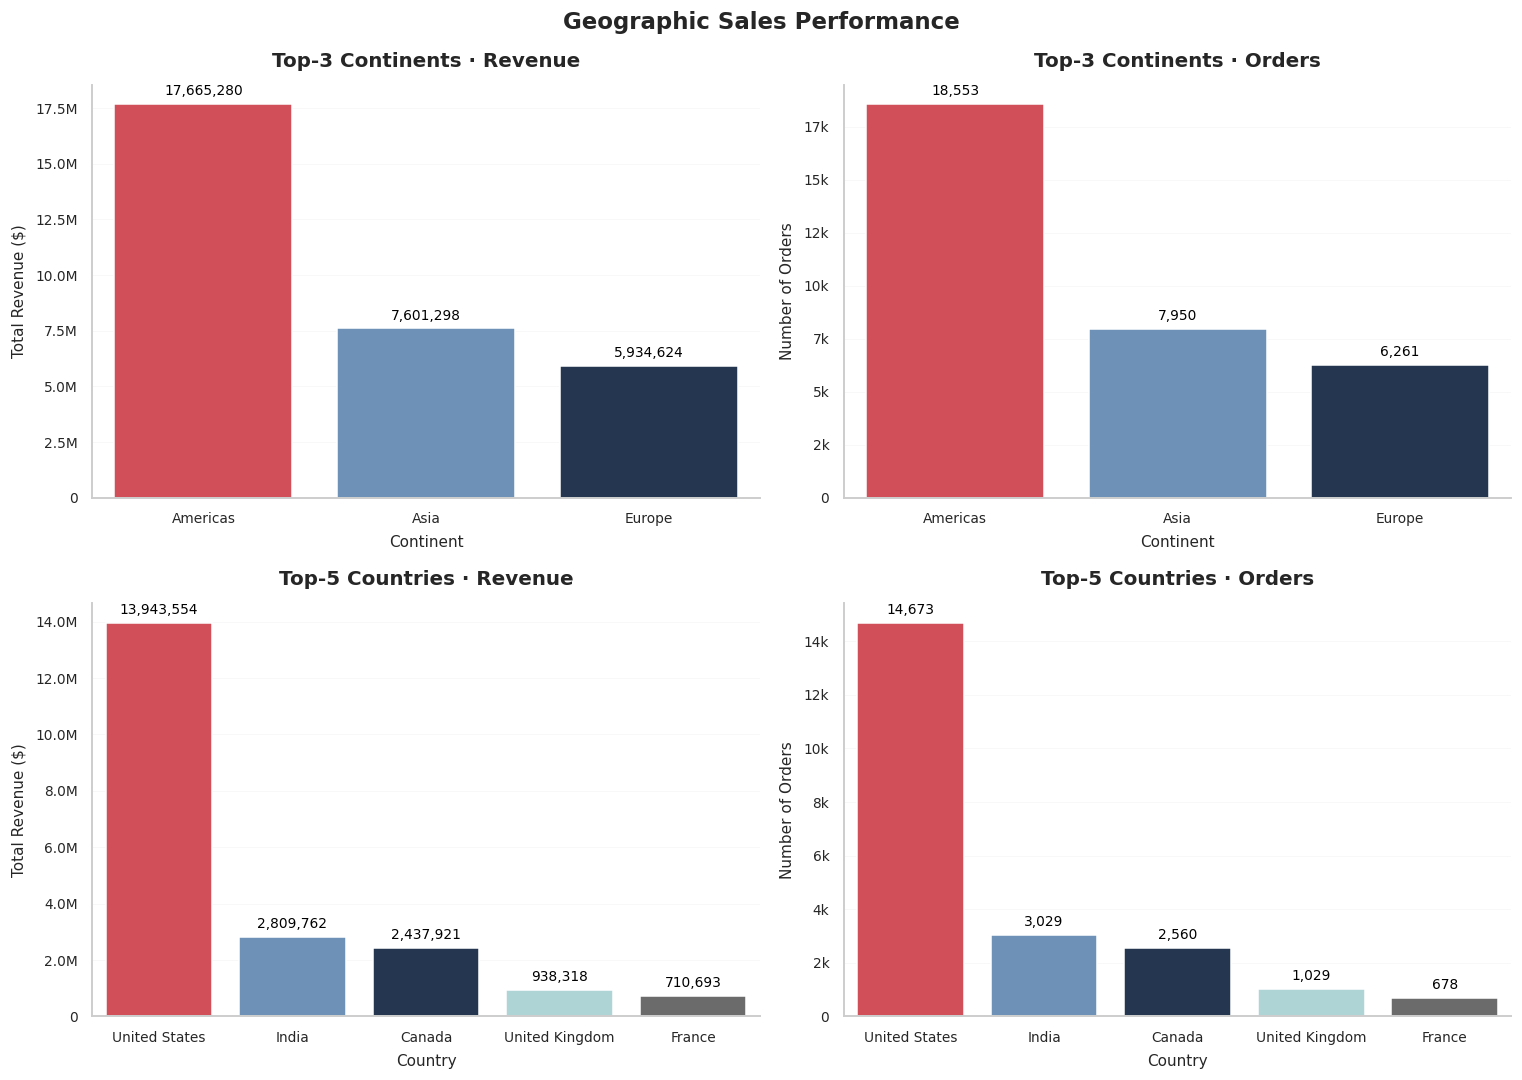

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Geographic Sales Performance")

# Top-3 Continents by Revenue
ax = axes[0, 0]
sns.barplot(data=top3_continents_revenue, x="continent", y="product_price",
            palette=PALETTE_3, ax=ax)
add_bar_labels(ax)
apply_k_formatter(ax, "y")
ax.set_title("Top-3 Continents · Revenue")
ax.set_xlabel("Continent")
ax.set_ylabel("Total Revenue ($)")

# Top-3 Continents by Order Count
ax = axes[0, 1]
sns.barplot(data=top3_continents_orders, x="continent", y="id_session",
            palette=PALETTE_3, ax=ax)
add_bar_labels(ax)
apply_k_formatter(ax, "y")
ax.set_title("Top-3 Continents · Orders")
ax.set_xlabel("Continent")
ax.set_ylabel("Number of Orders")

# Top-5 Countries by Revenue
ax = axes[1, 0]
sns.barplot(data=top5_country_revenue, x="country", y="product_price",
            palette=PALETTE_5, ax=ax)
add_bar_labels(ax)
apply_k_formatter(ax, "y")
ax.set_title("Top-5 Countries · Revenue")
ax.set_xlabel("Country")
ax.set_ylabel("Total Revenue ($)")

# Top-5 Countries by Order Count
ax = axes[1, 1]
sns.barplot(data=top5_country_orders, x="country", y="id_session",
            palette=PALETTE_5, ax=ax)
add_bar_labels(ax)
apply_k_formatter(ax, "y")
ax.set_title("Top-5 Countries · Orders")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

- **Americas, Europe, and Asia** are the top-3 revenue continents, with the **United States** alone accounting for the largest single-country share of total revenue.
- The gap between the #1 country and the #2–3 countries is $ 11,133,792 — indicating a heavily concentrated market.
- Revenue ranking and order-count ranking for the top-5 countries match , which means high-revenue countries are also driven by order volume .

## Product Categories

In [ ]:
# Top-10 categories globally (by revenue and by order count)

top10_categories_revenue = (
    ecomm.groupby("product_category")["product_price"]
    .sum().nlargest(10).sort_values(ascending=False).reset_index()
)
top10_categories_orders = (
    orders_df.groupby("product_category")["id_session"]
    .count().nlargest(10).sort_values(ascending=False).reset_index()
)

print("\nTop-10 categories (global, by revenue):\n",  top10_categories_revenue)
print("\nTop-10 categories (global, by orders):\n",   top10_categories_orders)


Top-10 categories (global, by revenue):
                    product_category  product_price
0                 Sofas & armchairs      8388254.5
1                            Chairs      6147748.8
2                              Beds      4919725.0
3        Bookcases & shelving units      3640818.1
4              Cabinets & cupboards      2336499.5
5                 Outdoor furniture      2142222.2
6                    Tables & desks      1790307.5
7  Chests of drawers & drawer units       906562.5
8                     Bar furniture       735503.0
9              Children's furniture       467697.0

Top-10 categories (global, by orders):
                    product_category  id_session
0        Bookcases & shelving units        7630
1                            Chairs        5952
2                 Sofas & armchairs        4301
3                    Tables & desks        2941
4                              Beds        2926
5              Cabinets & cupboards        2318
6                 Ou

In [ ]:
# Top-10 categories in the leading country (highest total revenue)

country_leader = ecomm.groupby("country")["product_price"].sum().idxmax()
df_leader = ecomm[ecomm["country"] == country_leader]

top10_categories_top_country = (
    df_leader.groupby("product_category")["product_price"]
    .sum().nlargest(10).sort_values(ascending=False).reset_index()
)

print(f"\nLeading country: {country_leader}")
print(f"\nTop-10 categories in {country_leader}:\n",  top10_categories_top_country)


Leading country: United States

Top-10 categories in United States:
                    product_category  product_price
0                 Sofas & armchairs      3707144.5
1                            Chairs      2619773.8
2                              Beds      2213058.0
3        Bookcases & shelving units      1567606.9
4              Cabinets & cupboards       994545.5
5                 Outdoor furniture       929245.2
6                    Tables & desks       777865.0
7  Chests of drawers & drawer units       382388.0
8                     Bar furniture       330805.0
9              Children's furniture       207575.0


/tmp/ipykernel_9413/1727451593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_categories_revenue,
/tmp/ipykernel_9413/1727451593.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_categories_top_country,


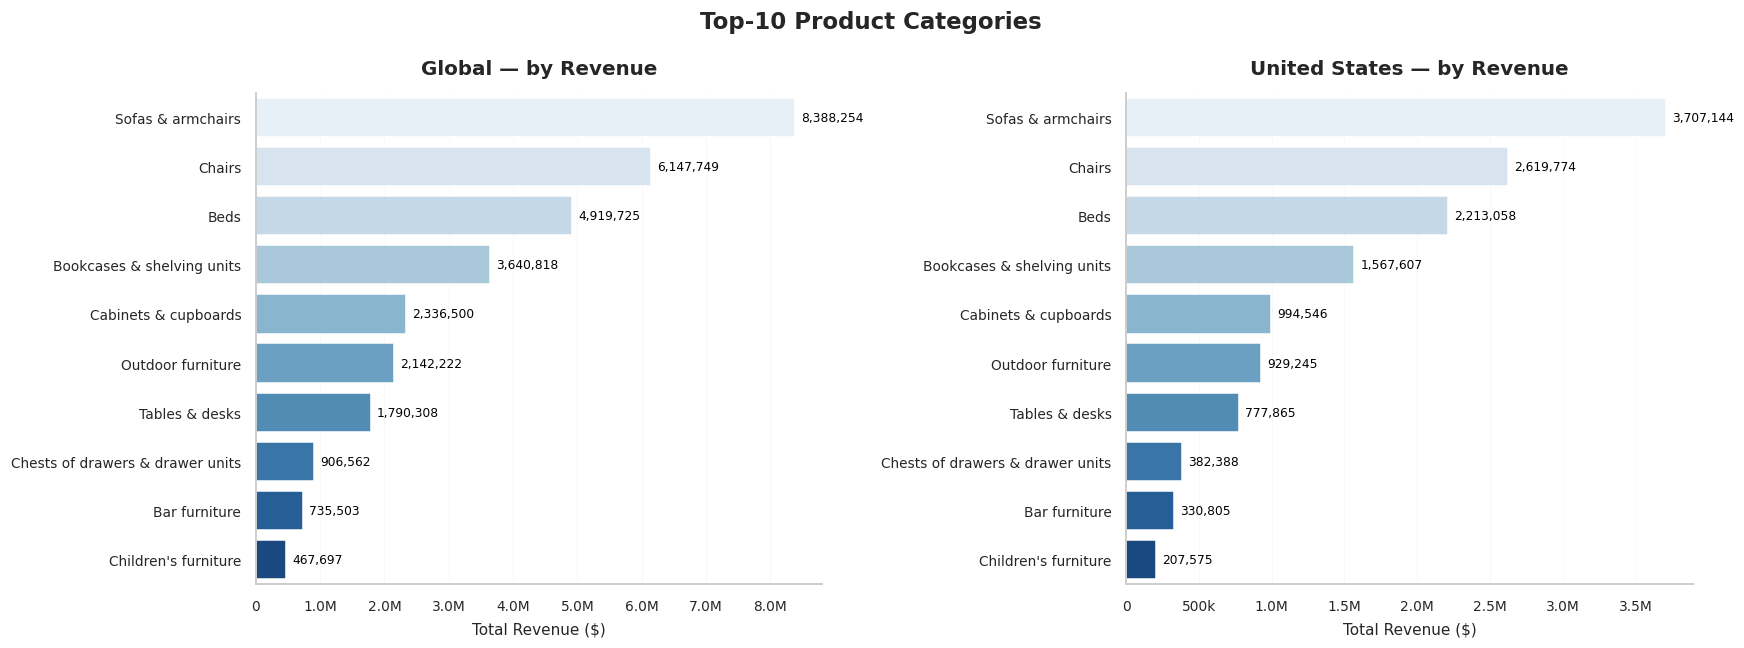

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top-10 Product Categories")

# Global revenue ranking
ax = axes[0]
sns.barplot(data=top10_categories_revenue,
            y="product_category", x="product_price",
            palette=PALETTE_MANY, orient="h", ax=ax)
apply_k_formatter(ax, "x")
add_bar_labels(ax, fmt="{:,.0f}", padding=4, fontsize=8)
ax.set_title("Global — by Revenue")
ax.set_xlabel("Total Revenue ($)")
ax.set_ylabel("")

# Leading-country revenue ranking
ax = axes[1]
sns.barplot(data=top10_categories_top_country,
            y="product_category", x="product_price",
            palette=PALETTE_MANY, orient="h", ax=ax)
apply_k_formatter(ax, "x")
add_bar_labels(ax, fmt="{:,.0f}", padding=4, fontsize=8)
ax.set_title(f"{country_leader} — by Revenue")
ax.set_xlabel("Total Revenue ($)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

- The core revenue drivers - **Sofas & Armchairs, Chairs and Beds** - generate the overwhelming majority of total sales.

- The category ranking in **United States** mirrors the global ranking exactly confirming that United States is a reliable proxy market for forecasting global category trends.



## Device & Traffic source

In [ ]:
total_revenue = ecomm["product_price"].sum()

# Revenue percentages by device type
device_revenue = ecomm.groupby("device")["product_price"].sum().sort_values(ascending=False)
device_pct     = (device_revenue / total_revenue * 100).round(2)

# Revenue percentages by traffic source
source_revenue = ecomm.groupby("traffic_source")["product_price"].sum().sort_values(ascending=False)
source_pct     = (source_revenue / total_revenue * 100).round(2)

# Revenue percentages by traffic channel
channel_revenue = ecomm.groupby("traffic_channel")["product_price"].sum().sort_values(ascending=False)
channel_pct     = (channel_revenue / total_revenue * 100).round(2)

print("\nRevenue share by device:          \n", device_pct)
print("\nRevenue share by traffic source:  \n", source_pct)
print("\nRevenue share by traffic channel: \n", channel_pct)



Revenue share by device:          
 device
desktop    59.00
mobile     38.73
tablet      2.26
Name: product_price, dtype: float64

Revenue share by traffic source:  
 traffic_source
(organic)         34.20
(direct)          23.44
<Other>           18.45
(referral)        17.65
(data deleted)     6.26
Name: product_price, dtype: float64

Revenue share by traffic channel: 
 traffic_channel
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: product_price, dtype: float64


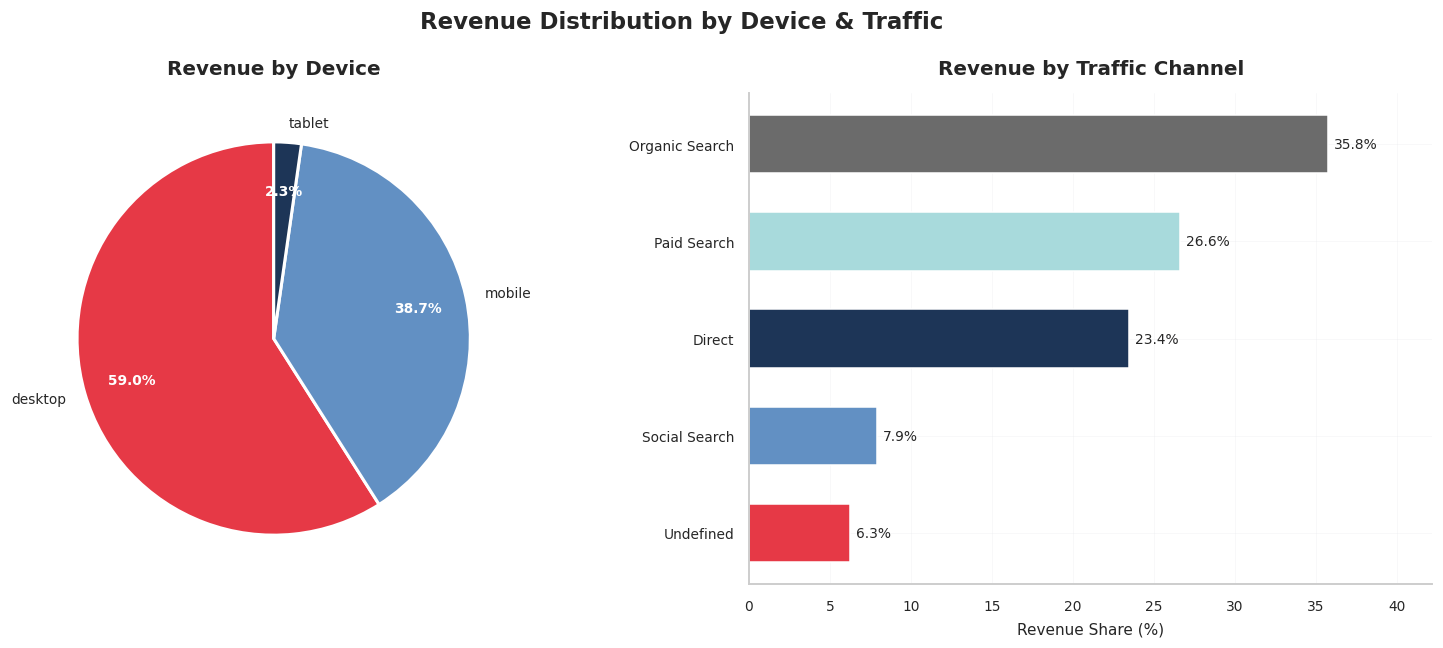

In [ ]:
fig = plt.figure(figsize=(14, 6))
fig.suptitle("Revenue Distribution by Device & Traffic")

gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

# Pie chart — device split
ax0 = fig.add_subplot(gs[0, 0])
wedge_colors = PALETTE_3[: len(device_pct)]
wedges, texts, autotexts = ax0.pie(
    device_pct, labels=device_pct.index,
    colors=wedge_colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
ax0.set_title("Revenue by Device")

# Horizontal bar — traffic channel (top 8)
ax1 = fig.add_subplot(gs[0, 1])
top_channels = channel_pct.sort_values()
bars = ax1.barh(top_channels.index, top_channels.values,
                color=PALETTE_5, height=0.6)
ax1.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax1.set_xlabel("Revenue Share (%)")
ax1.set_title("Revenue by Traffic Channel")
ax1.set_xlim(0, top_channels.max() * 1.18)

plt.tight_layout()
plt.show()

- **Desktop** drives **~59% of revenue** — typical for high-consideration furniture purchases that benefit from larger screens during research.

- **Organic Search (34%) and Direct Traffic (23%)** traffic source form a strong, sustainable baseline, indicating excellent SEO health and strong brand loyalty.



## User Account Metrics

In [ ]:
# Registrated users data

registrated_users = ecomm[ecomm["id_account"].notna()].copy()

In [ ]:
# Email verification and unsubscribe rates among registered users

email_verified_pct  = registrated_users["email_verified"].mean() * 100
unsubscribed_pct    = registrated_users["is_unsubscribed"].mean() * 100

print(f"\nEmail-verified users  : {email_verified_pct:.2f}%")
print(f"Unsubscribed users    : {unsubscribed_pct:.2f}%")

# Compare purchasing behaviour between subscribed and unsubscribed users.
sales_by_sub = (
    registrated_users.groupby("is_unsubscribed")["product_price"]
    .agg(
        total_revenue="sum",
        avg_order_value="mean",
        order_count="count",
    )
    .round(2)
    .rename(index={False: "Subscribed", True: "Unsubscribed"})
)
print("\nSales by subscription status:\n", sales_by_sub)


Email-verified users  : 71.70%
Unsubscribed users    : 16.94%

Sales by subscription status:
                  total_revenue  avg_order_value  order_count
is_unsubscribed                                             
Subscribed           2150796.9           921.51         2334
Unsubscribed          431721.6           965.82          447


In [ ]:
# Top-10 countries by registered users who made a purchase

countries_reg = (
    registrated_users[registrated_users["product_price"].notna()]
    .groupby("country")["id_session"]
    .count()
    .nlargest(10)
    .sort_values(ascending=False)
    .reset_index()
)
print("\nTop-10 countries (registered users with purchases):\n", countries_reg)


Top-10 countries (registered users with purchases):
           country  id_session
0   United States        1207
1           India         246
2          Canada         207
3  United Kingdom          88
4          France          56
5         Germany          56
6          Taiwan          51
7           China          48
8           Spain          48
9       Singapore          44


In [ ]:
# Conversion Rate by Country

total_sessions_country = ecomm.groupby('country')['id_session'].count()

sessions_with_purchase_country = orders_df.groupby('country')['id_session'].count()

conversion_rate = (sessions_with_purchase_country / total_sessions_country * 100).nlargest(10).sort_values(ascending=False)

print(conversion_rate.round(2))

country
Trinidad & Tobago    17.65
Jamaica              16.98
Malta                15.94
Georgia              14.29
Paraguay             12.86
Oman                 12.66
Qatar                 12.5
Finland              12.43
Pakistan             12.06
Serbia               11.87
Name: id_session, dtype: Float64


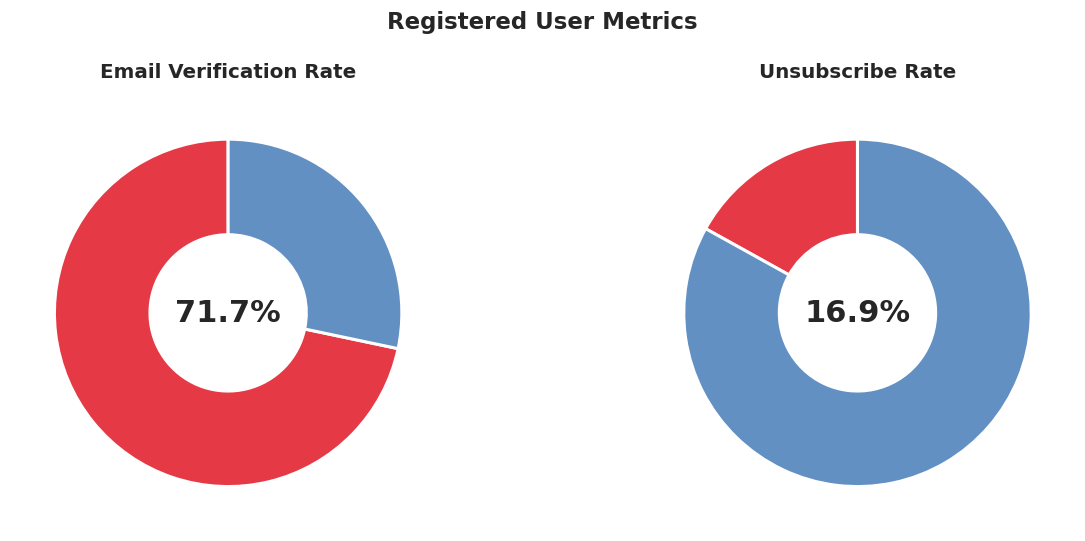

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Registered User Metrics")

# Gauge-style donut — email verification rate
ax = axes[0]
ax.pie(
    [email_verified_pct, 100 - email_verified_pct],
    colors=PALETTE_2, startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
)
ax.text(0, 0, f"{email_verified_pct:.1f}%", ha="center", va="center",
        fontsize=20, fontweight="bold")
ax.set_title("Email Verification Rate")

# Gauge-style donut — unsubscribe rate
ax = axes[1]
ax.pie(
    [unsubscribed_pct, 100 - unsubscribed_pct],
    colors=PALETTE_2, startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
)
ax.text(0, 0, f"{unsubscribed_pct:.1f}%", ha="center", va="center",
        fontsize=20, fontweight="bold")
ax.set_title("Unsubscribe Rate")

plt.tight_layout()
plt.show()



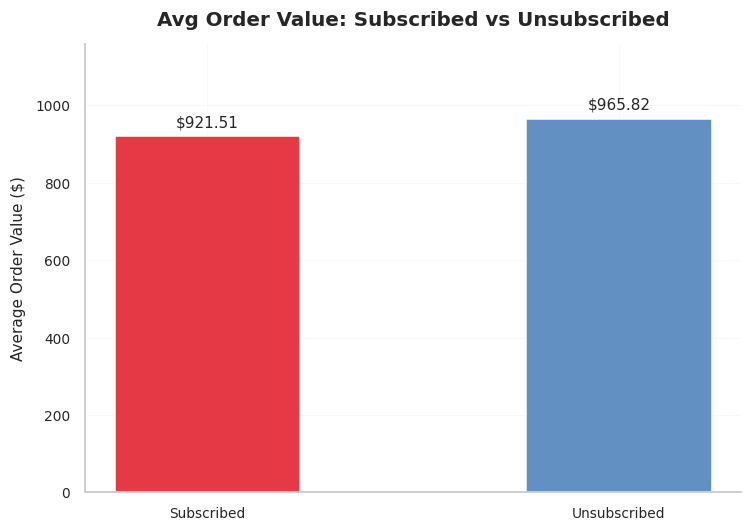

In [ ]:
# Grouped bar — Subscribed vs Unsubscribed AOV comparison
fig, ax = plt.subplots(figsize=(7, 5))

sub_labels = sales_by_sub.index.tolist()
aov_vals   = sales_by_sub["avg_order_value"].values
bars = ax.bar(sub_labels, aov_vals, color=PALETTE_2, width=0.45)

ax.bar_label(bars, fmt="${:,.2f}", padding=4, fontsize=10)
ax.set_title("Avg Order Value: Subscribed vs Unsubscribed")
ax.set_ylabel("Average Order Value ($)")
ax.set_ylim(0, max(aov_vals) * 1.20)

plt.tight_layout()
plt.show()

- **92% of sessions are anonymous** — registered-user acquisition remains a major untapped growth lever.

- Among registered users, the email-verification rate is **71.7%** and the unsubscribe rate is **16.9**.
- Comparing subscribed vs unsubscribed users: AOV differs by **$44.31**, meaning unsubscribed users still spend similarly.

## Key Performance Indicators

In [ ]:
# Global Conversion Rate
# (sessions that ended with a purchase / total sessions)
total_sessions   = ecomm["id_session"].count()
purchase_sessions = orders_df["id_session"].count()
conversion_rate_global = purchase_sessions / total_sessions * 100
print(f"\nGlobal Conversion Rate : {conversion_rate_global:.2f}%")

# KPI 2 — Global Average Order Value (AOV)
# AOV = total revenue / number of orders
total_revenue_orders = orders_df["product_price"].sum()
global_aov           = total_revenue_orders / purchase_sessions
print(f"Global AOV             : ${global_aov:.2f}")


Global Conversion Rate : 9.59%
Global AOV             : $953.30


In [ ]:
# Per-country Conversion Rate (top 10)
total_sessions_country    = ecomm.groupby("country")["id_session"].count()
purchase_sessions_country = orders_df.groupby("country")["id_session"].count()
cr_country = (
    (purchase_sessions_country / total_sessions_country * 100)
    .nlargest(10)
    .sort_values(ascending=False)
)
print("\nTop-10 countries by Conversion Rate (%):\n", cr_country.round(2))

# KPI 4 — Per-country AOV (min 10 orders; avoids noise from tiny samples)
country_aov_df = (
    orders_df.groupby("country")
    .agg(revenue=("product_price", "sum"), orders=("id_session", "count"))
)
country_aov_df["AOV"] = (country_aov_df["revenue"] / country_aov_df["orders"]).round(2)
top10_aov = (
    country_aov_df[country_aov_df["orders"] >= 10]["AOV"]
    .nlargest(10)
)
print("\nTop-10 countries by AOV (min 10 orders):\n", top10_aov)


Top-10 countries by Conversion Rate (%):
 country
Trinidad & Tobago    17.65
Jamaica              16.98
Malta                15.94
Georgia              14.29
Paraguay             12.86
Oman                 12.66
Qatar                 12.5
Finland              12.43
Pakistan             12.06
Serbia               11.87
Name: id_session, dtype: Float64

Top-10 countries by AOV (min 10 orders):
 country
Palestine     1747.69
Bulgaria      1518.11
Albania        1401.5
Venezuela     1396.77
Kenya         1373.48
Oman          1357.77
Algeria       1293.67
Lithuania     1282.25
Kazakhstan    1234.62
Jamaica       1199.56
Name: AOV, dtype: Float64


In [ ]:
# Revenue per Session by traffic channel
channel_kpi = ecomm.groupby("traffic_channel").agg(
    revenue        =("product_price", "sum"),
    total_sessions =("id_session",    "count"),
)
channel_kpi["revenue_per_session"] = (
    channel_kpi["revenue"] / channel_kpi["total_sessions"]
).round(2)

print("\nRevenue per Session by traffic channel:\n",
      channel_kpi["revenue_per_session"].sort_values(ascending=False))


Revenue per Session by traffic channel:
 traffic_channel
Undefined         93.12
Direct             92.1
Organic Search    91.89
Social Search     90.71
Paid Search       90.22
Name: revenue_per_session, dtype: Float64


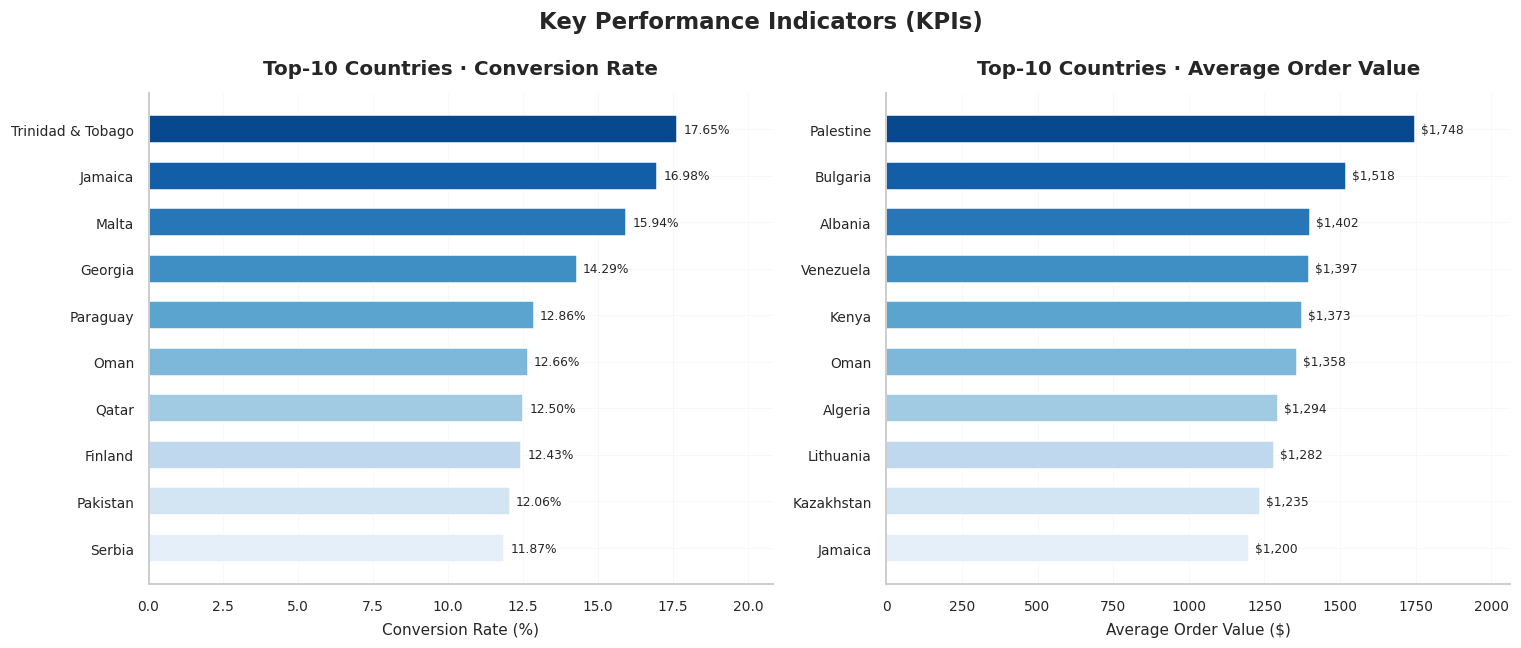

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Key Performance Indicators (KPIs)")

# Conversion rate by country (horizontal bar)
ax = axes[0]
cr_plot = cr_country.sort_values()
colors = sns.color_palette(PALETTE_MANY, n_colors=len(cr_plot))
ax.barh(cr_plot.index, cr_plot.values, color=colors, height=0.6)
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=4, fontsize=8)
ax.set_xlabel("Conversion Rate (%)")
ax.set_title("Top-10 Countries · Conversion Rate")
ax.set_xlim(0, cr_plot.max() * 1.18)

# AOV by country (horizontal bar)
ax = axes[1]
aov_plot = top10_aov.sort_values()
colors = sns.color_palette(PALETTE_MANY, n_colors=len(aov_plot))
ax.barh(aov_plot.index, aov_plot.values, color=colors, height=0.6)
ax.bar_label(ax.containers[0], fmt="${:,.0f}", padding=4, fontsize=8)
ax.set_xlabel("Average Order Value ($)")
ax.set_title("Top-10 Countries · Average Order Value")
ax.set_xlim(0, aov_plot.max() * 1.18)

plt.tight_layout()
plt.show()


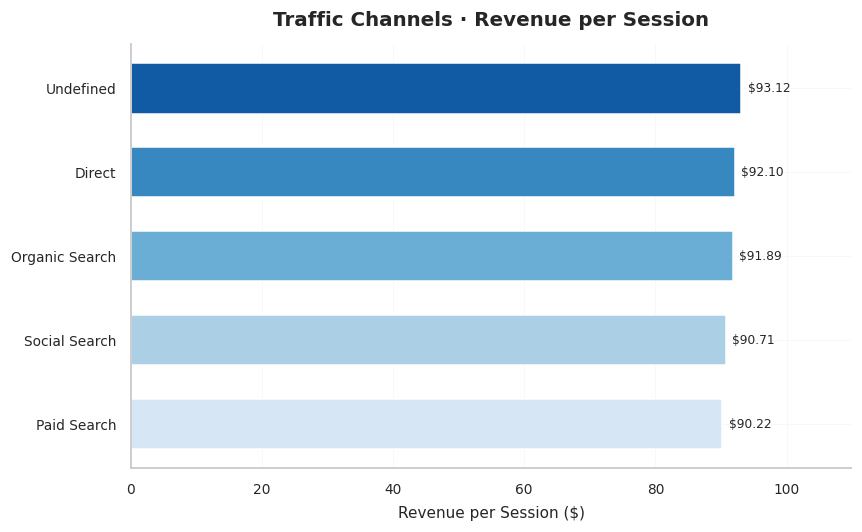

In [ ]:
# Revenue per session by channel (horizontal bar)
fig, ax = plt.subplots(figsize=(8, 5))
rps_plot = channel_kpi["revenue_per_session"].sort_values()
colors = sns.color_palette(PALETTE_MANY, n_colors=len(rps_plot))
ax.barh(rps_plot.index, rps_plot.values, color=colors, height=0.6)
ax.bar_label(ax.containers[0], fmt="${:,.2f}", padding=4, fontsize=8)
ax.set_xlabel("Revenue per Session ($)")
ax.set_title("Traffic Channels · Revenue per Session")
ax.set_xlim(0, rps_plot.max() * 1.18)

plt.tight_layout()
plt.show()

While the **global conversion rate** sits at **9.59%**, countries like **Trinidad & Tobago** significantly outperform the baseline. However, the highest CR does not always correlate with the highest total revenue, highlighting the difference between niche, high-converting markets and large-volume markets.

The **Direct channel** delivers the highest **Revenue per Session** **($92.10)**, proving to be the most commercially valuable acquisition source, whereas Paid Search serves more as a top-of-funnel awareness driver.

# Sales trends over time

## Overall Daily Trend & Weekly Seasonality

In [ ]:
# Daily revenue aggregation

sales_trend = ecomm.groupby("session_date")["product_price"].sum().reset_index()

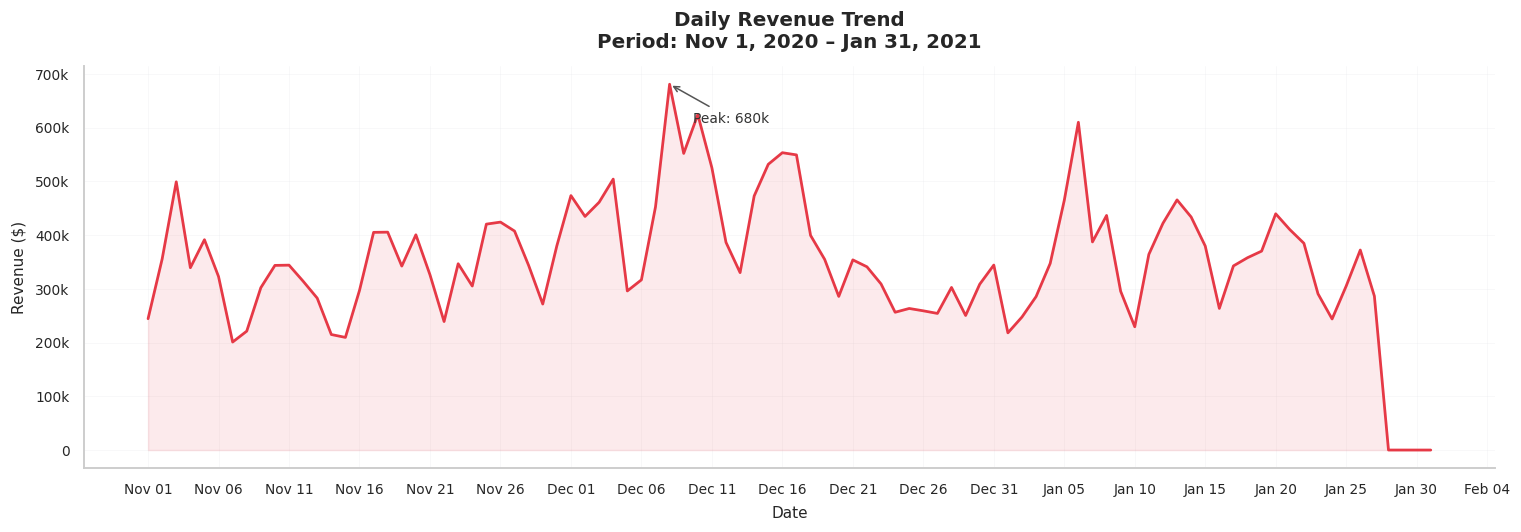

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(
    data=sales_trend,
    x="session_date", y="product_price",
    color=COLOR_SINGLE, linewidth=1.8, ax=ax,
)
# Shade the area under the line for visual impact
ax.fill_between(
    sales_trend["session_date"], sales_trend["product_price"],
    alpha=0.10, color=COLOR_SINGLE,
)
# Annotate the all-time peak
peak_row = sales_trend.loc[sales_trend["product_price"].idxmax()]
ax.annotate(
    f"Peak: {k_formatter(peak_row['product_price'], None)}",
    xy=(peak_row["session_date"], peak_row["product_price"]),
    xytext=(15, -25), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#555"),
    fontsize=9, color="#333",
)
ax.set_title("Daily Revenue Trend\nPeriod: Nov 1, 2020 – Jan 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
apply_k_formatter(ax, "y")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

Daily revenue follows a consistent weekly cycle (mid-week peaks, weekend dips) overlaid with a single major seasonal spike around Dec 8, $680K, most likely tied to holiday-season promotions.

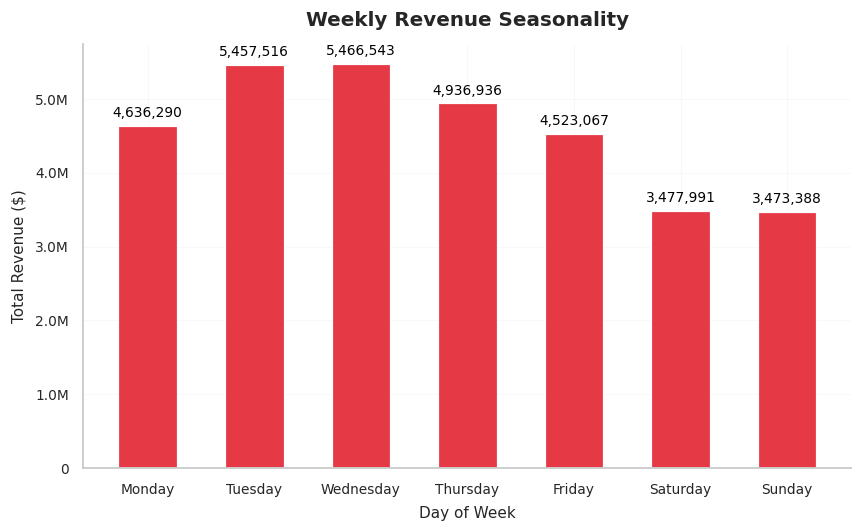

In [ ]:
# Aggregate total revenue by weekday to detect intra-week patterns.
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sales_day = ecomm.groupby("day_name")["product_price"].sum().reset_index()
sales_day["day_name"] = pd.Categorical(sales_day["day_name"],
                                       categories=weekday_order, ordered=True)
sales_day = sales_day.sort_values("day_name")

# Weekly Seasonality

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sales_day["day_name"], sales_day["product_price"],
       color=COLOR_SINGLE, width=0.55, edgecolor="white", linewidth=0.8)
add_bar_labels(ax, fmt="{:,.0f}", fontsize=9)
apply_k_formatter(ax, "y")
ax.set_title("Weekly Revenue Seasonality")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()


An analysis by day of the week shows that the highest sales occur on Tuesday to Thursday, which may indicate a B2B component to the business, as private buyers tend to shop more often at the weekend".


## Trends by Segment

In [ ]:
# Select the three continents that generated the most revenue overall.
top_continents = (
    ecomm.groupby("continent")["product_price"]
    .sum().nlargest(3).index
)
sales_continents_trend = (
    ecomm[ecomm["continent"].isin(top_continents)]
    .groupby(["session_date", "continent"])["product_price"]
    .sum().reset_index()
)


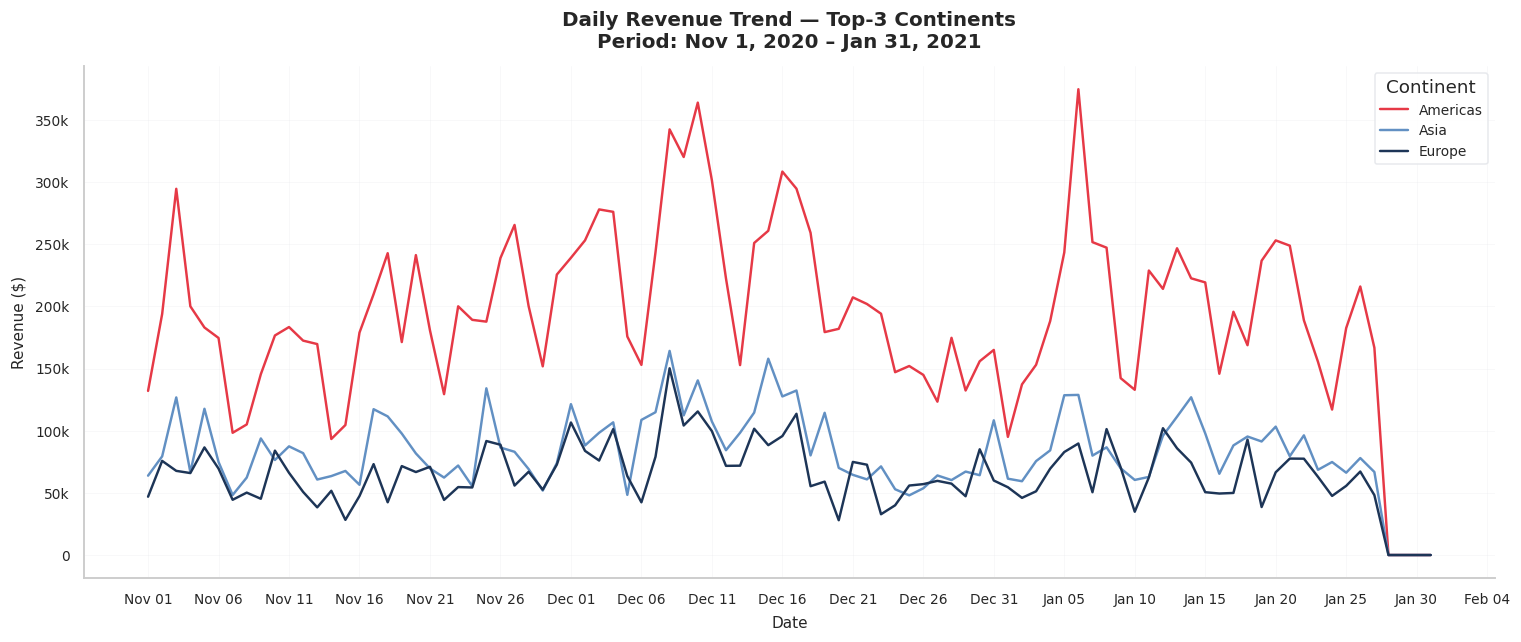

In [ ]:
# Revenue by Continent

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=sales_continents_trend,
    x="session_date", y="product_price",
    hue="continent", palette=PALETTE_3,
    linewidth=1.6, ax=ax,
)
ax.set_title("Daily Revenue Trend — Top-3 Continents\nPeriod: Nov 1, 2020 – Jan 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
apply_k_formatter(ax, "y")
ax.legend(title="Continent")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()


- The relative ranking between continents stays consistent across the period.
- Americas shows the most volatile revenue pattern, while Asia and Europe exhibit blunter day-to-day swings — possibly due to smaller sample size .

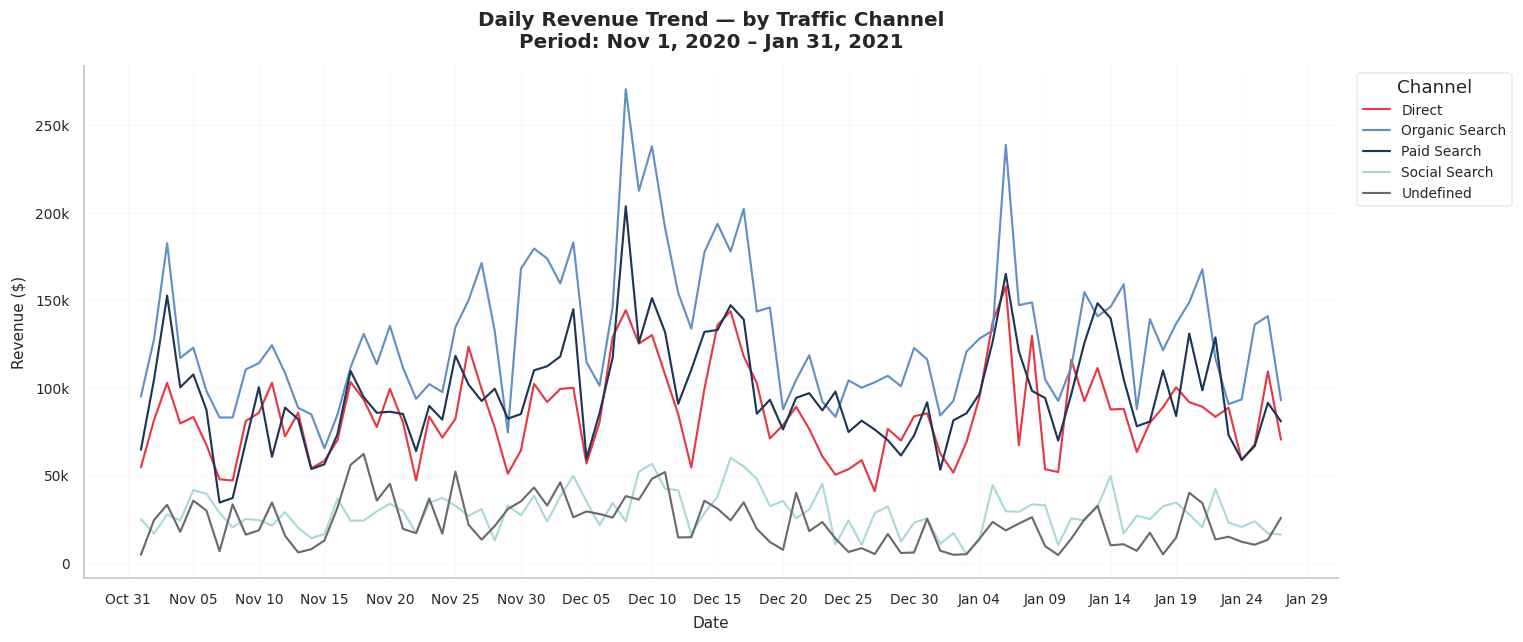

In [ ]:
# Revenue by Traffic Channel

sales_channel_trend = (
    orders_df.groupby(["session_date", "traffic_channel"])["product_price"]
    .sum().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=sales_channel_trend,
    x="session_date", y="product_price",
    hue="traffic_channel", palette=PALETTE_5,
    linewidth=1.4, ax=ax,
)
ax.set_title("Daily Revenue Trend — by Traffic Channel\nPeriod: Nov 1, 2020 – Jan 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
apply_k_formatter(ax, "y")
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

-  Organic Search consistently leads in daily revenue, with Direct and Paid Search as stable secondary contributors.

- All of them show spiky behavior — likely tied to specific campaign on/off periods rather than organic demand.

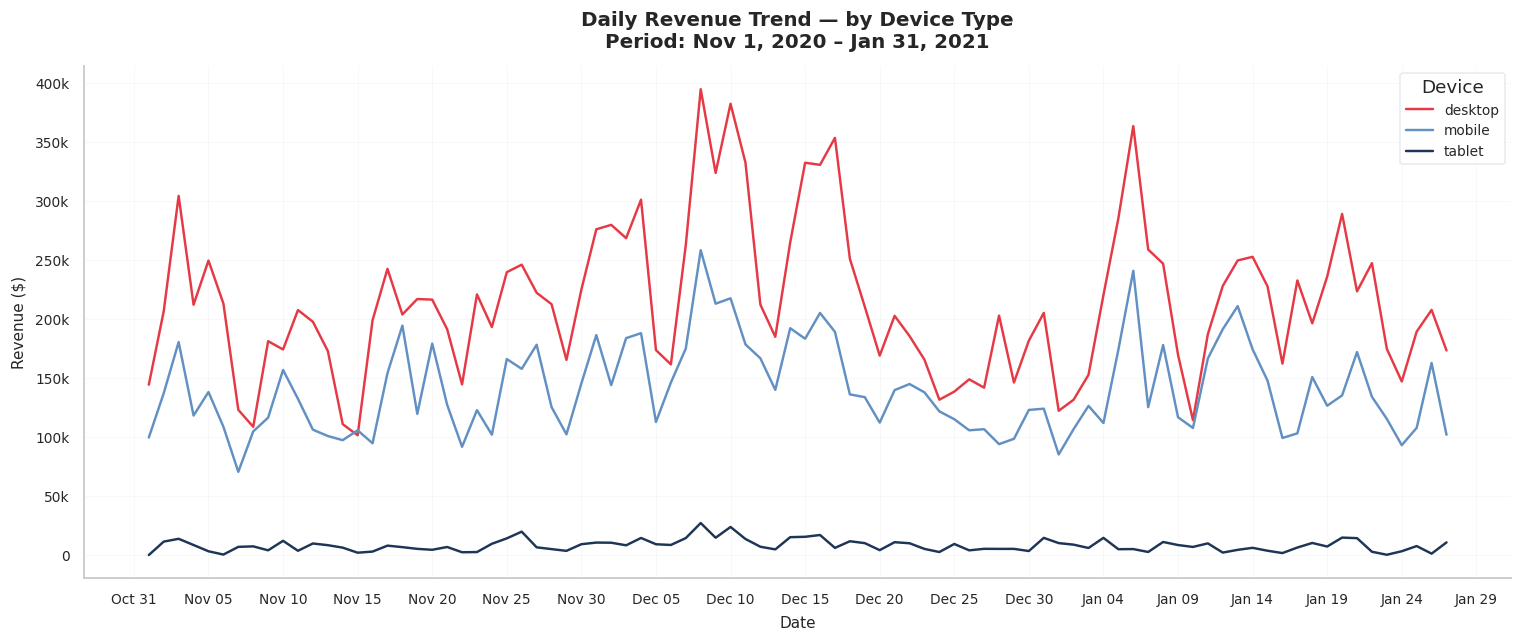

In [ ]:
# Device trend

sales_device_trend = (
    orders_df.groupby(["session_date", "device"])["product_price"]
    .sum().reset_index()
)

# Revenue by Device

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=sales_device_trend,
    x="session_date", y="product_price",
    hue="device", palette=PALETTE_3,
    linewidth=1.6, ax=ax,
)
ax.set_title("Daily Revenue Trend — by Device Type\nPeriod: Nov 1, 2020 – Jan 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
apply_k_formatter(ax, "y")
ax.legend(title="Device")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

- Desktop revenue tracks closely with the overall daily trend — confirming it as the primary driver of the patterns seen in the aggregate chart.
- Tablet revenue remain comparatively low throughout the period, with no clear weekly pattern.
- During the peak on 8 Dec, the increase was driven primarily by Desktop — suggesting that seasonal campaigns convert best on desktop.

In [ ]:
# Select the 5 categories that generated the most revenue overall.
top_categories = ecomm.groupby('product_category')['product_price'].sum().nlargest(5).index

sales_cat_trend = (
    ecomm[ecomm['product_category'].isin(top_categories)]
    .groupby(["session_date", "product_category"])["product_price"]
    .sum().reset_index()
)

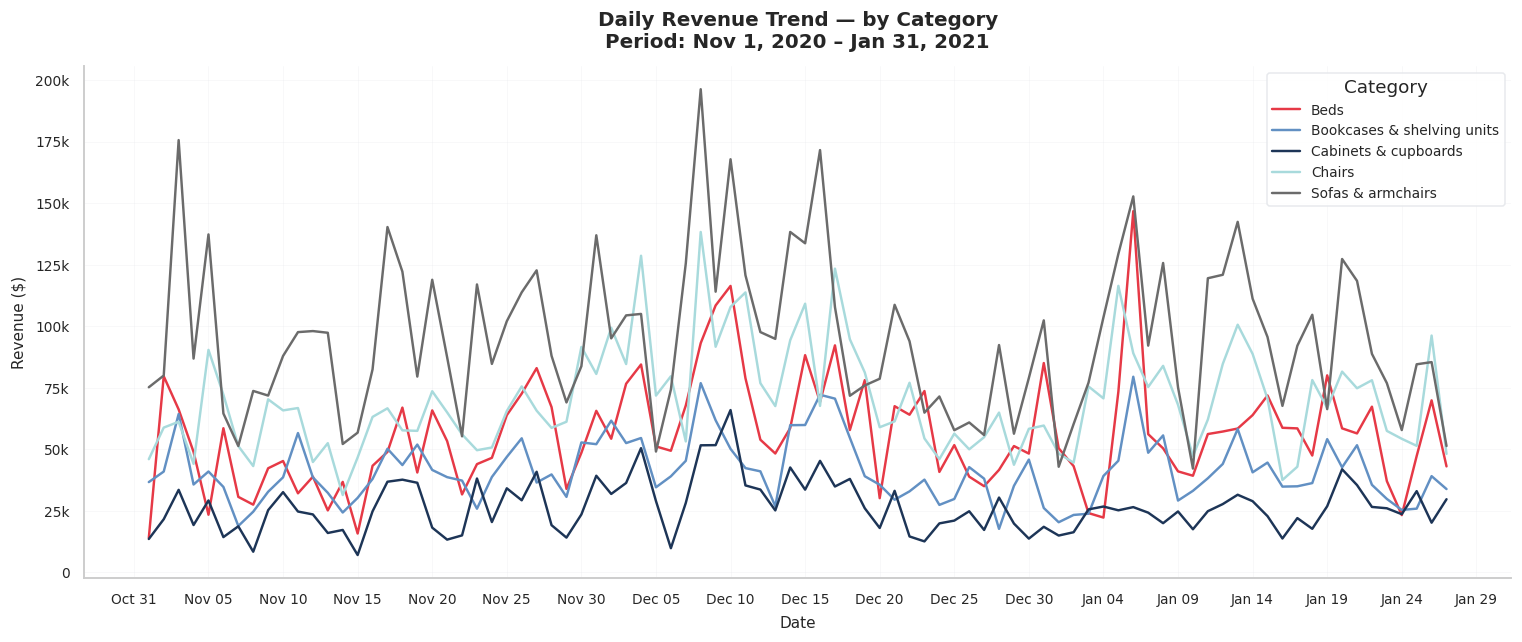

In [ ]:
# Revenue by Category

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data= sales_cat_trend,
    x="session_date", y="product_price",
    hue="product_category", palette=PALETTE_5,
    linewidth=1.6, ax=ax,
)
ax.set_title("Daily Revenue Trend — by Category\nPeriod: Nov 1, 2020 – Jan 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
apply_k_formatter(ax, "y")
ax.legend(title="Category")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

- Sofas & Armchairs  maintains the highest daily revenue throughout almost the entire period, confirming it as the structural revenue leader rather than a one-off top performer.
- The spike on Dec 8 is driven mainly by Sofas & Armchairs — reinforcing its role as the primary seasonal driver
- Cabinets & cupboards shows no clear trend across the period.

# Pivot tables & heatmaps

## Sessions: Channel × Device

In [ ]:
# Sessions: Traffic Channel × Device

# Remove rows where either dimension is unknown / unset,
INVALID = {"(not set)", "unknown", "None", None}

df_valid_ch_dev = ecomm[
    ecomm["device"].notna()          & (~ecomm["device"].isin(INVALID)) &
    ecomm["traffic_channel"].notna() & (~ecomm["traffic_channel"].isin(INVALID))
]

pivot_sessions = df_valid_ch_dev.pivot_table(
    index="traffic_channel",
    columns="device",
    values="id_session",
    aggfunc="count",
    fill_value=0,
)

pivot_sessions = pivot_sessions.astype(float)
print("\nPivot — Sessions by Channel × Device:\n", pivot_sessions)


Pivot — Sessions by Channel × Device:
 device           desktop   mobile  tablet
traffic_channel                          
Direct           47825.0  31745.0  1812.0
Organic Search   72622.0  49014.0  2789.0
Paid Search      55167.0  37034.0  2140.0
Social Search    16288.0  10988.0   638.0
Undefined        12527.0   8486.0   470.0


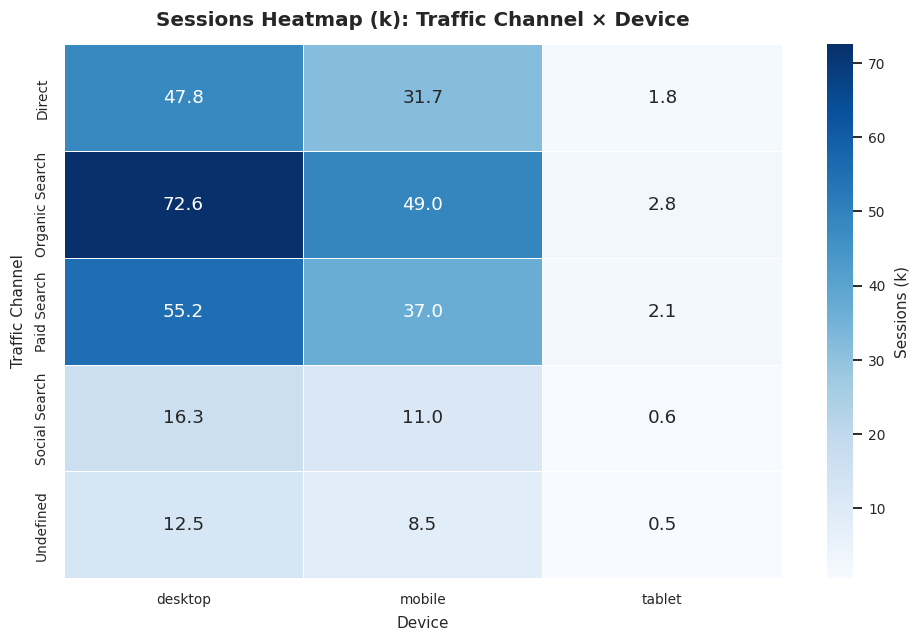

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_sessions / 1_000, annot=True, fmt=".1f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Sessions (k)"},
    ax=ax,
)
ax.set_title("Sessions Heatmap (k): Traffic Channel × Device")
ax.set_xlabel("Device")
ax.set_ylabel("Traffic Channel")

plt.tight_layout()
plt.show()

## Revenue: Categories × Countries

In [ ]:
# Revenue: Top-10 Categories × Top-5 Countries

top_5_countries  = orders_df.groupby("country")["product_price"].sum().nlargest(5).index
top_10_cats      = orders_df.groupby("product_category")["product_price"].sum().nlargest(10).index

df_top_sales = orders_df[
    orders_df["country"].isin(top_5_countries) &
    orders_df["product_category"].isin(top_10_cats)
]

sales_pivot = df_top_sales.pivot_table(
    index="product_category",
    columns="country",
    values="product_price",
    aggfunc="sum",
    fill_value=0,
)
# Maintain the ranking order in rows and columns
sales_pivot = sales_pivot.loc[top_10_cats, top_5_countries]
print("\nPivot — Revenue Top-10 Categories × Top-5 Countries:\n", sales_pivot.round(0))



Pivot — Revenue Top-10 Categories × Top-5 Countries:
 country                           United States     India    Canada  \
product_category                                                      
Sofas & armchairs                     3707144.0  788430.0  692428.0   
Chairs                                2619774.0  544309.0  417741.0   
Beds                                  2213058.0  358320.0  354772.0   
Bookcases & shelving units            1567607.0  364507.0  278982.0   
Cabinets & cupboards                   994546.0  191888.0  181802.0   
Outdoor furniture                      929245.0  162289.0  185323.0   
Tables & desks                         777865.0  186158.0  132678.0   
Chests of drawers & drawer units       382388.0   73111.0   71952.0   
Bar furniture                          330805.0   57657.0   51724.0   
Children's furniture                   207575.0   39177.0   30264.0   

country                           United Kingdom    France  
product_category               

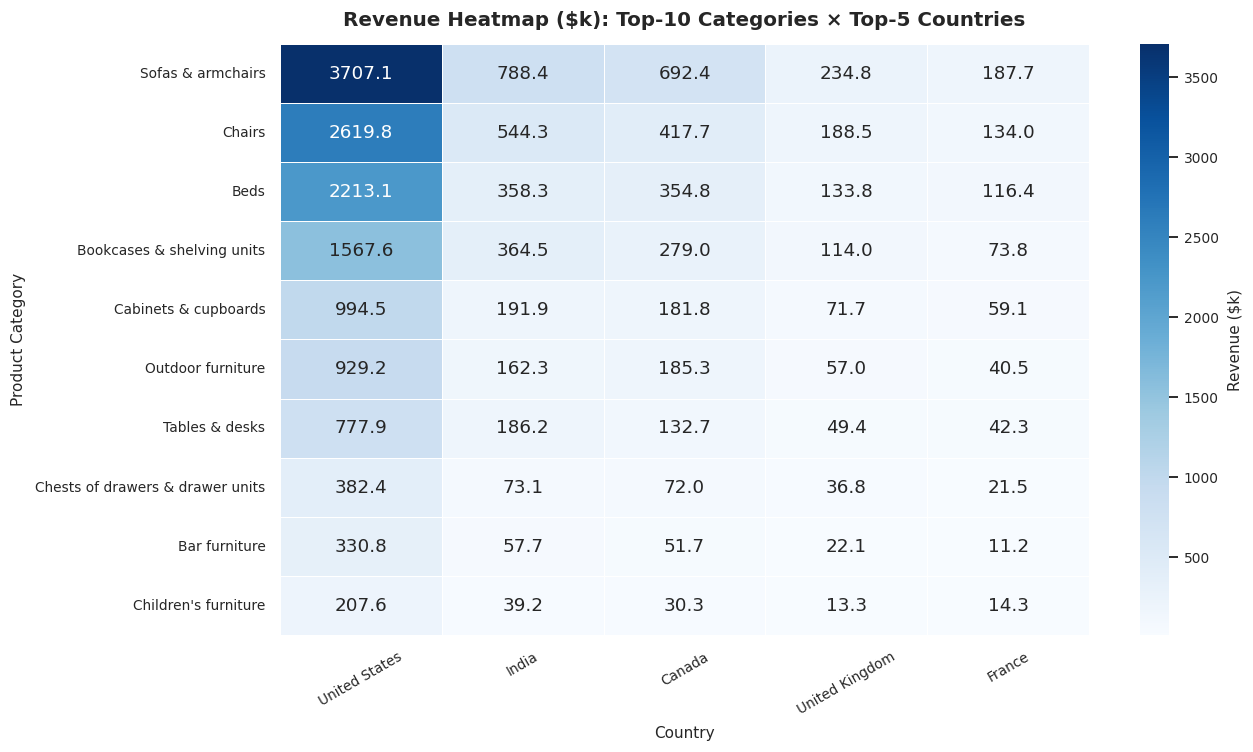

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    sales_pivot / 1_000,
    annot=True, fmt=".1f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Revenue ($k)"},
    ax=ax,
)
ax.set_title("Revenue Heatmap ($k): Top-10 Categories × Top-5 Countries")
ax.set_xlabel("Country")
ax.set_ylabel("Product Category")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## AOV: Continent × Device

In [ ]:
# AOV: Continent × Device

pivot_aov_raw = orders_df.groupby(["continent", "device"]).agg(
    revenue=("product_price", "sum"),
    orders =("id_session",    "count"),
).reset_index()
pivot_aov_raw["AOV"] = pivot_aov_raw["revenue"] / pivot_aov_raw["orders"]

pivot_aov = pivot_aov_raw.pivot(
    index="continent", columns="device", values="AOV"
).fillna(0)

pivot_aov = pivot_aov.astype(float)
print("\nPivot — AOV: Continent × Device:\n", pivot_aov.round(0))



Pivot — AOV: Continent × Device:
 device     desktop  mobile  tablet
continent                         
(not set)   1033.0  1118.0    70.0
Africa      1030.0   907.0   987.0
Americas     962.0   936.0   967.0
Asia         940.0   971.0  1111.0
Europe       955.0   935.0   978.0
Oceania     1039.0   943.0   848.0


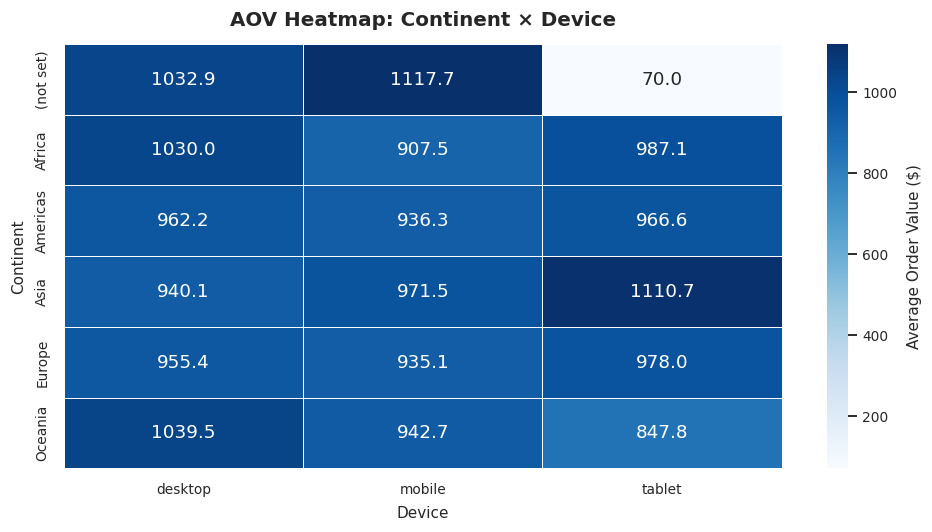

In [ ]:
# AOV heatmap
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_aov, annot=True, fmt=".1f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Average Order Value ($)"},
    ax=ax,
)
ax.set_title("AOV Heatmap: Continent × Device")
ax.set_xlabel("Device")
ax.set_ylabel("Continent")

plt.tight_layout()
plt.show()

## Revenue: Weekday × Channel

In [ ]:
# Week Day Revenue by Traffic Channel

weekday_channel_pivot = orders_df.pivot_table(
    index="traffic_channel",
    columns="day_name",
    values="product_price",
    aggfunc="sum",
    fill_value=0,
)

weekday_channel_pivot = weekday_channel_pivot[weekday_order]
print("\nPivot — Revenue per Day of Week × Traffic Channel:\n", weekday_channel_pivot)


Pivot — Revenue per Day of Week × Traffic Channel:
 day_name            Monday    Tuesday  Wednesday   Thursday     Friday  \
traffic_channel                                                          
Direct           1142469.8  1332097.4  1295161.3  1084474.2  1079529.3   
Organic Search   1625823.1  1934027.0  1907089.8  1755329.0  1624368.1   
Paid Search      1205662.5  1476921.3  1444449.0  1340922.6  1170256.9   
Social Search     356146.1   377128.2   412756.8   412418.1   392862.0   
Undefined         306188.9   337342.0   407086.0   343791.7   256050.9   

day_name          Saturday     Sunday  
traffic_channel                        
Direct            788576.4   772615.0  
Organic Search   1302765.6  1283749.0  
Paid Search       924709.4   948127.7  
Social Search     305475.4   275319.1  
Undefined         156464.1   193577.4  


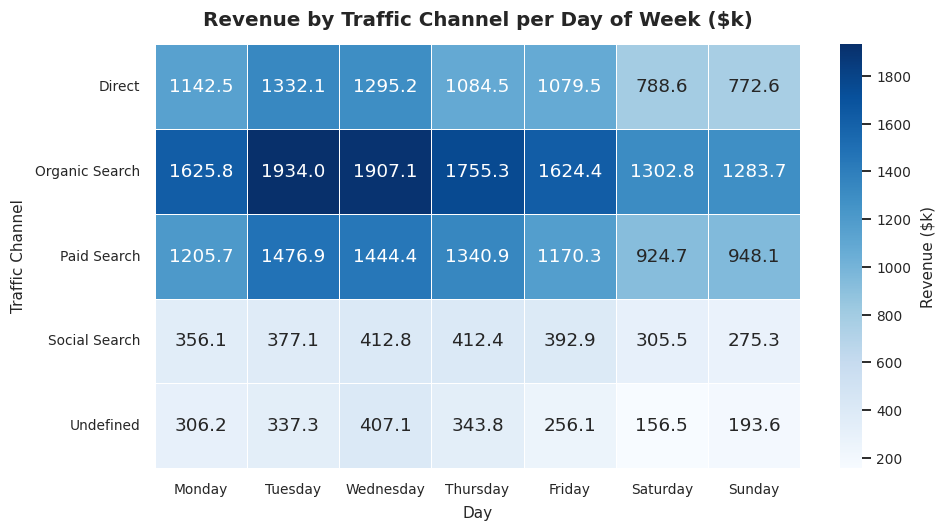

In [ ]:
# Week Day Revenue by Channel heatmap

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    weekday_channel_pivot / 1000,
    annot=True, fmt=".1f",
    cmap="Blues",
    linewidths=0.4,
    cbar_kws={"label": "Revenue ($k)"},
    ax=ax,
)
ax.set_title("Revenue by Traffic Channel per Day of Week ($k)")
ax.set_xlabel("Day")
ax.set_ylabel("Traffic Channel")
ax.tick_params(axis="x")

plt.tight_layout()
plt.show()

- The heatmap reveals a massive concentration of sessions arriving via **Organic Search** on **Desktop**.

- **Sofas & Armchairs** dominate revenue across nearly all top-5 countries, confirming this category as a universal demand driver rather than a regional preference.

- The AOV heatmap identifies **[Asia × Tablet]** as the highest-value segment (**$1110.7**) versus **[Oceania × Tablet]** as the lowest (**$847.8**), a difference of **$269.90** — likely reflecting regional purchasing power or product-mix differences.

- The weekday × channel revenue table shows **Organic Search peaking on Tuesday/Wednesday**, reinforcing the mid-week revenue pattern seen in the overall trend.

# Statistical analysis of correlations

## Sessions vs Revenue

In [ ]:
# Correlation: Session and revenue by day

daily_metrics = ecomm.groupby('session_date').agg(
    total_sessions=('id_session', 'count'),
    total_revenue=('product_price', 'sum')
).reset_index()

# Check for a normal distribution
stat, p_norm_sr = stats.normaltest(daily_metrics['total_revenue'])
print(f"Normality test  p-value: {p_norm_sr:.4f}  {'→ NOT normal' if p_norm_sr < 0.05 else '→ normal'}") # 0.0211 < 0.05, non-normal distribution -> Use Spearman method

# Spearman's correlation and p-value
corr_sp, p_sp = stats.spearmanr(daily_metrics['total_sessions'], daily_metrics['total_revenue'])
print(f"Spearman's correlation coefficient: {corr_sp:.4f}")
print(f"Statistical significance (p-value): {p_sp:.4f}")

Normality test  p-value: 0.0211  → NOT normal
Spearman's correlation coefficient: 0.8653
Statistical significance (p-value): 0.0000


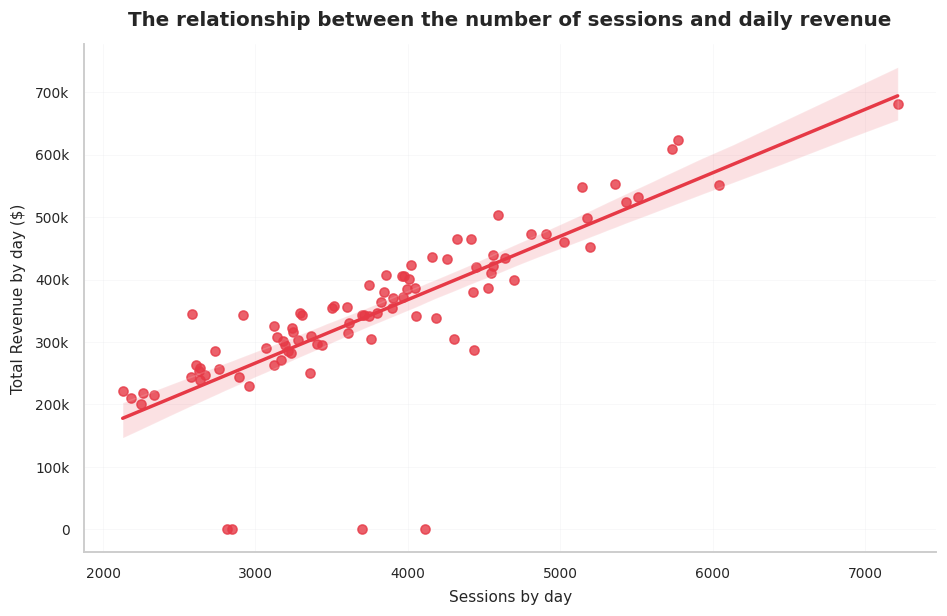

In [ ]:
#  (Scatter plot + trend line)
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=daily_metrics, x='total_sessions', y='total_revenue', color= COLOR_SINGLE, ax=ax)
ax.set_title('The relationship between the number of sessions and daily revenue')
ax.set_xlabel('Sessions by day')
ax.set_ylabel('Total Revenue by day ($)')
apply_k_formatter(ax, "y")

plt.show()

## By Continent

In [ ]:
# Correlation: Daily Revenue by Top-3 Continents

#  Check for a normal distribution
stat, p_norm_cont = stats.normaltest(sales_continents_trend["product_price"])
print(f"Normality test p-value: {p_norm_cont:.4f}  {'→ NOT normal' if p_norm_cont < 0.05 else '→ normal'}")

# Correlation matrix
sales_continents_matrix = sales_continents_trend.pivot(
    index='session_date',
    columns='continent',
    values='product_price'
).fillna(0)

corr_continent_matrix = sales_continents_matrix.corr(method='spearman')
print("\nSpearman's Correlation Matrix (continents)")
print(corr_continent_matrix.round(4))

# Spearman's correlation and p-value
corr_am_as, p_am_as = stats.spearmanr(sales_continents_matrix["Americas"], sales_continents_matrix["Asia"])
corr_am_eu, p_am_eu = stats.spearmanr(sales_continents_matrix["Americas"], sales_continents_matrix["Europe"])
corr_eu_as, p_eu_as = stats.spearmanr(sales_continents_matrix["Europe"], sales_continents_matrix["Asia"])

print("\nStatistical signification of correlations (continents)")
print(f"Americas vs Asia: Spearman's r = {corr_am_as:.4f}, p-value = {p_am_as:.4f}")
print(f"Americas vs Europe: Spearman's r = {corr_am_eu:.4f}, p-value = {p_am_eu:.4f}")
print(f"Europe vs Asia: Spearman's r = {corr_eu_as:.4f}, p-value = {p_eu_as:.4f}")


Normality test p-value: 0.0000  → NOT normal

Spearman's Correlation Matrix (continents)
continent  Americas    Asia  Europe
continent                          
Americas     1.0000  0.7099  0.6726
Asia         0.7099  1.0000  0.6571
Europe       0.6726  0.6571  1.0000

Statistical signification of correlations (continents)
Americas vs Asia: Spearman's r = 0.7099, p-value = 0.0000
Americas vs Europe: Spearman's r = 0.6726, p-value = 0.0000
Europe vs Asia: Spearman's r = 0.6571, p-value = 0.0000


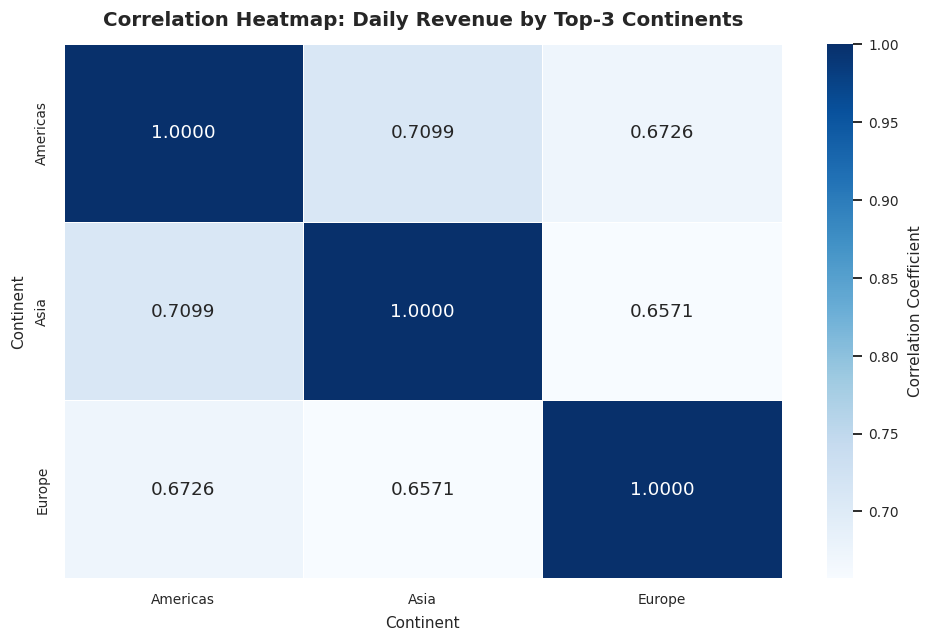

In [ ]:
# Top-3 Continent Revenue heatmap

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_continent_matrix, annot=True, fmt=".4f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Correlation Coefficient"},
    ax=ax,
)
ax.set_title("Correlation Heatmap: Daily Revenue by Top-3 Continents")
ax.set_xlabel("Continent")
ax.set_ylabel("Continent")

plt.tight_layout()
plt.show()

## By Traffic Channel

In [ ]:
# Correlation: Daily Revenue by Traffic Channel

#  Check for a normal distribution
stat, p_norm_ch = stats.normaltest(sales_channel_trend["product_price"])
print(f"Normality test p-value: {p_norm_ch:.4f}  {'→ NOT normal' if p_norm_ch < 0.05 else '→ normal'}")

# Correlation matrix

sales_channels_matrix = sales_channel_trend.pivot(
    index='session_date',
    columns='traffic_channel',
    values='product_price'
).fillna(0)

corr_channel_matrix = sales_channels_matrix.corr(method='spearman')

print("\nSpearman's Correlation Matrix ")
print(corr_channel_matrix.round(4))

print("\nStatistical signification of correlations (channels)")
channels_list = corr_channel_matrix.columns.tolist()
for i in range(len(channels_list)):
    for j in range(i + 1, len(channels_list)):
        ch1 = channels_list[i]
        ch2 = channels_list[j]
        r, p = stats.spearmanr(sales_channels_matrix[ch1], sales_channels_matrix[ch2])
        status = "Statistically significant" if p < 0.05 else "Not statistically significant"
        print(f"{ch1} vs {ch2}: Spearman r = {r:.4f}, p-value = {p:.4f} ({status})")


Normality test p-value: 0.0000  → NOT normal

Spearman's Correlation Matrix 
traffic_channel  Direct  Organic Search  Paid Search  Social Search  Undefined
traffic_channel                                                               
Direct           1.0000          0.7482       0.6908         0.3937     0.4937
Organic Search   0.7482          1.0000       0.7639         0.3848     0.4569
Paid Search      0.6908          0.7639       1.0000         0.4204     0.4933
Social Search    0.3937          0.3848       0.4204         1.0000     0.3859
Undefined        0.4937          0.4569       0.4933         0.3859     1.0000

Statistical signification of correlations (channels)
Direct vs Organic Search: Spearman r = 0.7482, p-value = 0.0000 (Statistically significant)
Direct vs Paid Search: Spearman r = 0.6908, p-value = 0.0000 (Statistically significant)
Direct vs Social Search: Spearman r = 0.3937, p-value = 0.0001 (Statistically significant)
Direct vs Undefined: Spearman r = 0.4937, p-

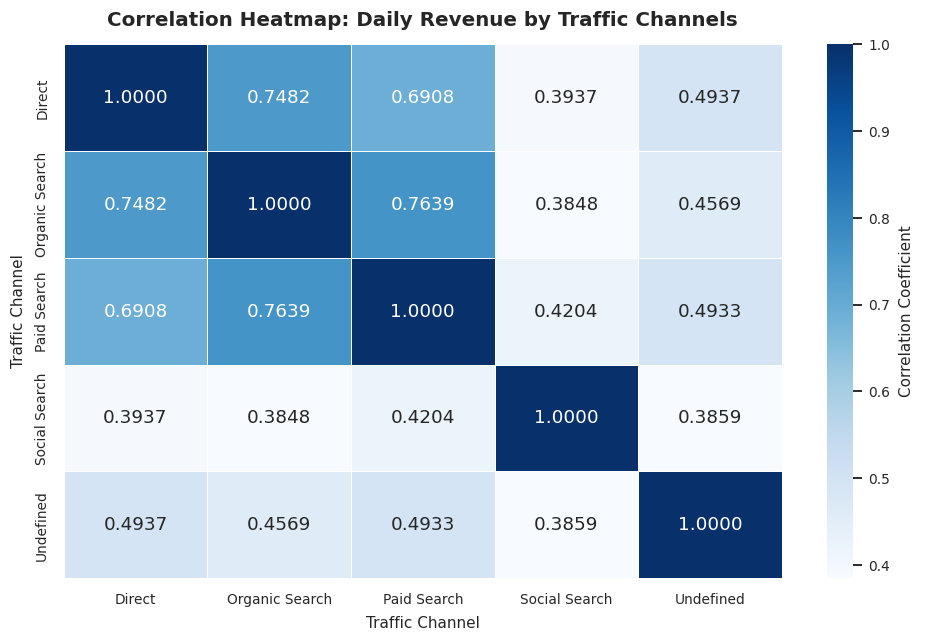

In [ ]:
# Channels Revenue heatmap

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_channel_matrix, annot=True, fmt=".4f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Correlation Coefficient"},
    ax=ax,
)
ax.set_title("Correlation Heatmap: Daily Revenue by Traffic Channels")
ax.set_xlabel("Traffic Channel")
ax.set_ylabel("Traffic Channel")

plt.tight_layout()
plt.show()

## By Product Category

In [ ]:
# Correlation: Daily Revenue by Top-5 Product Categories

#  Check for a normal distribution
stat, p_norm_cat = stats.normaltest(sales_cat_trend ["product_price"])
print(f"Normality test p-value: {p_norm_cat:.4f}  {'→ NOT normal' if p_norm_cat < 0.05 else '→ normal'}")

# Correlation matrix
sales_categories_matrix = sales_cat_trend.pivot(
    index='session_date',
    columns='product_category',
    values='product_price'
).fillna(0)

corr_categories_matrix = sales_categories_matrix.corr(method='spearman')
print("\nSpearman's Correlation Matrix (categories)")
print(corr_categories_matrix.round(4))

print("\nStatistical signification of correlations (categories)")
for i in range(len(top_categories)):
    for j in range(i + 1, len(top_categories)):
        cat1 = top_categories[i]
        cat2 = top_categories[j]
        r, p = stats.spearmanr(sales_categories_matrix[cat1], sales_categories_matrix[cat2])
        status = "Statistically significant" if p < 0.05 else "Not statistically significant"
        print(f"{cat1} vs {cat2}: Spearman r = {r:.4f}, p-value = {p:.4f} ({status})")


Normality test p-value: 0.0000  → NOT normal

Spearman's Correlation Matrix (categories)
product_category              Beds  Bookcases & shelving units  \
product_category                                                 
Beds                        1.0000                      0.5427   
Bookcases & shelving units  0.5427                      1.0000   
Cabinets & cupboards        0.4404                      0.5287   
Chairs                      0.5349                      0.6368   
Sofas & armchairs           0.5217                      0.6256   

product_category            Cabinets & cupboards  Chairs  Sofas & armchairs  
product_category                                                             
Beds                                      0.4404  0.5349             0.5217  
Bookcases & shelving units                0.5287  0.6368             0.6256  
Cabinets & cupboards                      1.0000  0.5268             0.6312  
Chairs                                    0.5268  1.0000  

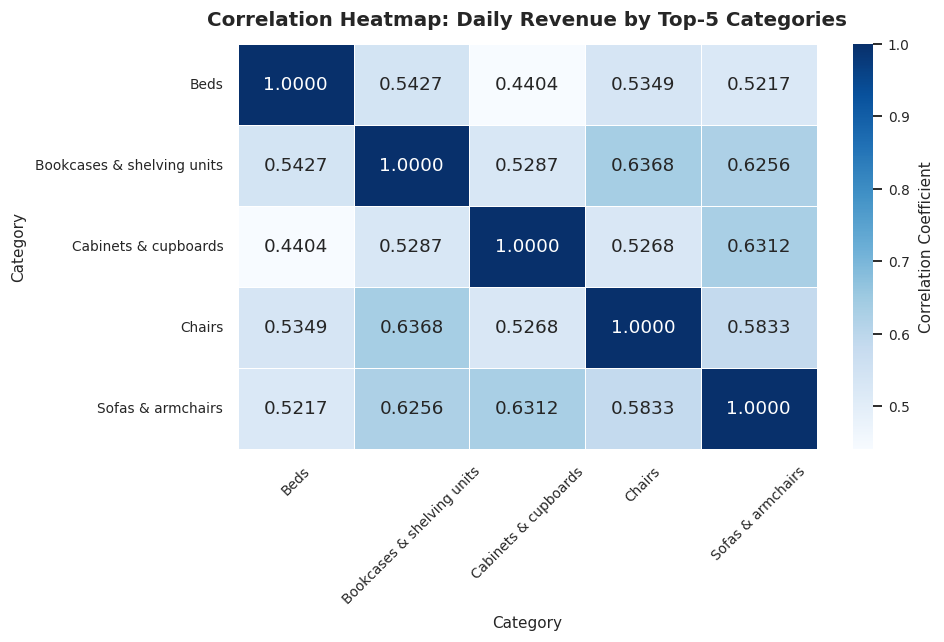

In [ ]:
# Top-5 Categories Revenue heatmap

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_categories_matrix, annot=True, fmt=".4f",
    cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "Correlation Coefficient"},
    ax=ax,
)
ax.set_title("Correlation Heatmap: Daily Revenue by Top-5 Categories")
ax.set_xlabel("Category")
ax.set_ylabel("Category")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- Spearman’s r = 0.8653, p-value = 0.0000. The correlation is strong and statistically significant . This means that an increase in the number of sessions is accompanied by a proportional increase in revenue — that is, conversion is stable from day to day.

- Of the three pairs, the strongest correlation is observed between Americas and Asia (r = 7090), other continents market have also strong corelation.

- Paid Search / Organic Search and Direct / Organic Search have the highest correlation and they are statistically significant.

# Statistical tests

## Mann-Whitney U - Registered vs Anonymous Users

In [ ]:
#  Registered vs Anonymous — daily revenue
# Hypothesis: do registered users generate significantly different revenue per day compared to anonymous sessions?

# Daily revenue per each group
registered_daily = (
    ecomm[ecomm['id_account'].notna()]
    .groupby('session_date')['product_price']
    .sum()
)
anonymous_daily = (
    ecomm[ecomm['id_account'].isna()]
    .groupby('session_date')['product_price']
    .sum()
)

# Check for a normal distribution
_, p_norm_reg  = stats.normaltest(registered_daily.dropna())
_, p_norm_anon = stats.normaltest(anonymous_daily.dropna())
print(f"Normality — registered  p = {p_norm_reg:.4f}  {'→ NOT normal' if p_norm_reg < 0.05 else '→ normal'}")
print(f"Normality — anonymous   p = {p_norm_anon:.4f}  {'→ NOT normal' if p_norm_anon < 0.05 else '→ normal'}")

# Choose Mann-Whitney U (non-parametric) because: there no normality destribution and there are 2 groups

u_stat, p_mw = stats.mannwhitneyu(
    registered_daily.dropna(),
    anonymous_daily.dropna(),
    alternative='two-sided'
)
print(f"Mann-Whitney U: Registered vs Anonymous (daily revenue) p-value: {p_mw:.4f}")

# Descriptive stats
print("  Registered  — median daily revenue: $", registered_daily.median())
print("  Anonymous   — median daily revenue: $", anonymous_daily.median())

Normality — registered  p = 0.0109  → NOT normal
Normality — anonymous   p = 0.0264  → NOT normal
Mann-Whitney U: Registered vs Anonymous (daily revenue) p-value: 0.0000
  Registered  — median daily revenue: $ 28048.0
  Anonymous   — median daily revenue: $ 315170.75


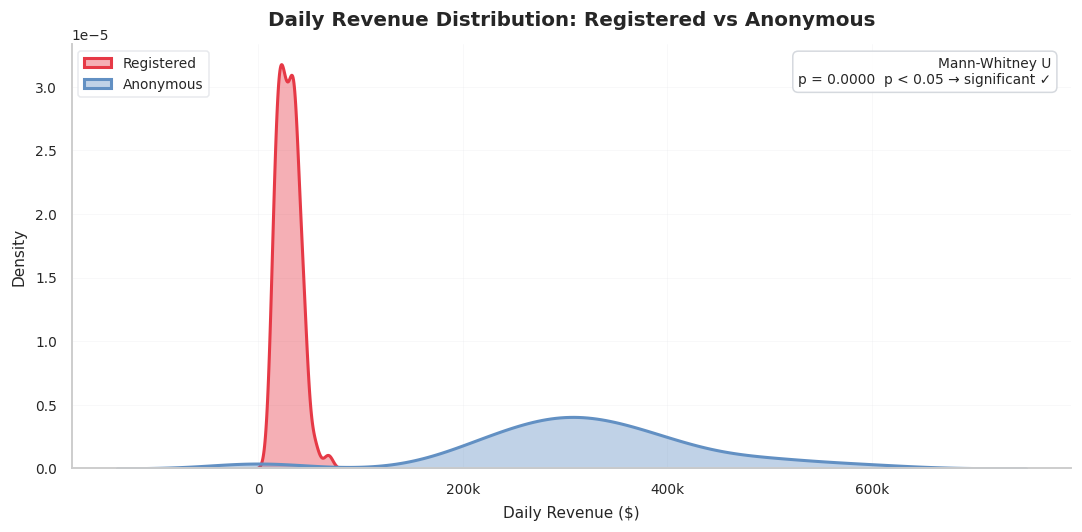

In [ ]:
# KDE plot — Registered vs Anonymous daily revenue

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(registered_daily.dropna(), ax=ax,
            color=PALETTE_2[0], fill=True, alpha=0.4,
            linewidth=2, label="Registered")

sns.kdeplot(anonymous_daily.dropna(), ax=ax,
            color=PALETTE_2[1], fill=True, alpha=0.4,
            linewidth=2, label="Anonymous")

ax.set_title("Daily Revenue Distribution: Registered vs Anonymous")
ax.set_xlabel("Daily Revenue ($)")
ax.set_ylabel("Density")
ax.legend()
apply_k_formatter(ax, "x")

result_pw = "p < 0.05 → significant ✓" if p_mw < 0.05 else "p ≥ 0.05 → not significant ✗"
ax.text(0.98, 0.97, f"Mann-Whitney U\np = {p_mw:.4f}  {result_pw}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#D1D5DB", alpha=0.9))

plt.tight_layout()
plt.show()

## Kruskal-Wallis - Sessions Across Traffic Channels

In [ ]:
# Sessions across traffic channels
# Hypothesis: are there significant differences in daily session counts between traffic channels?

# Daily sessions per channel
channel_daily_sessions = (
       ecomm[~ecomm['traffic_channel'].isin(INVALID)]
       .groupby(['session_date', 'traffic_channel'])['id_session']
       .count()
       .reset_index()
       .rename(columns={'id_session': 'sessions'})
)

channel_groups = {
    ch: grp['sessions'].values
    for ch, grp in channel_daily_sessions.groupby('traffic_channel')
}

# Check for a normal distribution
_, p_norm_chn  = stats.normaltest(channel_daily_sessions["sessions"].dropna())
print(f"Normality test p-value = {p_norm_chn:.4f}  {'→ NOT normal' if p_norm_chn < 0.05 else '→ normal'}")

# Choose Kruskal-Wallis because: there no normality destribution and there are 3+ groups

kw_stat, p_kw = stats.kruskal(*channel_groups.values())
print(f"Kruskal-Wallis: Sessions across traffic channels: {p_kw:4f}")


# Dunn post-hoc
if p_kw < 0.05:
    print("\n  Post-hoc pairwise comparisons (Mann-Whitney + Bonferroni):\n")

    # Сreate unique channel pair
    channel_pairs = list(combinations(channel_groups.keys(), 2))
    n_comparisons = len(channel_pairs)

    dunn_results = []
    for a, b in channel_pairs:
        _, p = stats.mannwhitneyu(channel_groups[a], channel_groups[b], alternative='two-sided')
        p_corr = min(p * n_comparisons, 1.0) # Bonferroni

        dunn_results.append({
            "Channel A": a,
            "Channel B": b,
            "p (Bonferroni)": round(p_corr, 5),
            "Significant": "✓" if p_corr < 0.05 else "✗"
        })

    print(pd.DataFrame(dunn_results).to_string(index=False))

Normality test p-value = 0.0000  → NOT normal
Kruskal-Wallis: Sessions across traffic channels: 0.000000

  Post-hoc pairwise comparisons (Mann-Whitney + Bonferroni):

     Channel A      Channel B  p (Bonferroni) Significant
        Direct Organic Search         0.00000           ✓
        Direct    Paid Search         0.00116           ✓
        Direct  Social Search         0.00000           ✓
        Direct      Undefined         0.00000           ✓
Organic Search    Paid Search         0.00000           ✓
Organic Search  Social Search         0.00000           ✓
Organic Search      Undefined         0.00000           ✓
   Paid Search  Social Search         0.00000           ✓
   Paid Search      Undefined         0.00000           ✓
 Social Search      Undefined         0.00001           ✓


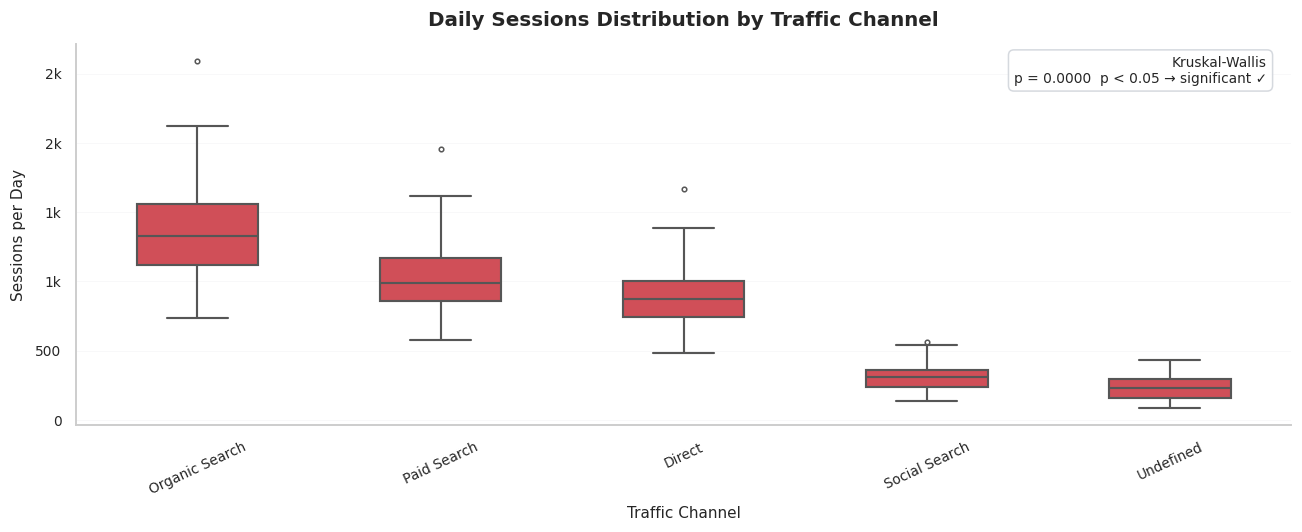

In [ ]:
# Box plot — Sessions by traffic channel ────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

channel_order = (
    channel_daily_sessions
    .groupby("traffic_channel")["sessions"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.boxplot(data=channel_daily_sessions,
            x="traffic_channel", y="sessions",
            order=channel_order,
            color= COLOR_SINGLE,
            width=0.5, linewidth=1.4, fliersize=3,
            ax=ax)

ax.set_title("Daily Sessions Distribution by Traffic Channel")
ax.set_xlabel("Traffic Channel")
ax.set_ylabel("Sessions per Day")
ax.tick_params(axis="x", rotation=25)
apply_k_formatter(ax, "y")

result_kw = "p < 0.05 → significant ✓" if p_kw < 0.05 else "p ≥ 0.05 → not significant ✗"
ax.text(0.98, 0.97, f"Kruskal-Wallis\np = {p_kw:.4f}  {result_kw}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#D1D5DB", alpha=0.9))

plt.tight_layout()
plt.show()

  ## Z-test
  
  Organic Traffic Share: Europe vs Americas

  Conversion Rate: Desktop vs Mobile

In [ ]:
# Organic traffic share: Europe vs Americas
# Hypothesis: is the proportion of organic sessions different between Europe and Americas?

for_prop = ecomm[ecomm['continent'].isin(['Europe', 'Americas'])].copy()

continent_totals  = for_prop.groupby('continent')['id_session'].count()
continent_organic = (
    for_prop[for_prop['traffic_channel'] == 'Organic Search']
    .groupby('continent')['id_session'].count()
)
# Choose Z-test for proportion because: there are 2 groups and binary data

count_organic = np.array([continent_organic['Europe'], continent_organic['Americas']])
count_total   = np.array([continent_totals['Europe'],  continent_totals['Americas']])

z_stat, p_z = proportions_ztest(count_organic, count_total)
print(f"Z-test for proportions: Organic share Europe vs Americas, {p_z:.4f}")
print("✓" if p_z < 0.05 else "✗", "Significant" if p_z < 0.05 else "No significant difference")

prop_eu  = count_organic[0] / count_total[0] * 100
prop_am  = count_organic[1] / count_total[1] * 100

print(f"  Europe   organic share: {prop_eu:.2f}%")
print(f"  Americas organic share: {prop_am:.2f}%")
print(f"  Difference            : {abs(prop_eu - prop_am):.2f} pp")

Z-test for proportions: Organic share Europe vs Americas, 0.7722
✗ No significant difference
  Europe   organic share: 35.61%
  Americas organic share: 35.55%
  Difference            : 0.06 pp


In [ ]:
# Conversion rate: Desktop vs Mobile
# Hypothesis: does the conversion rate differ between desktop and mobile?


for_conv = ecomm[ecomm['device'].isin(['desktop', 'mobile'])].copy()

device_totals    = for_conv.groupby('device')['id_session'].count()
device_converted = (
    for_conv[for_conv['product_price'].notna()]
    .groupby('device')['id_session'].count()
    .reindex(device_totals.index, fill_value=0)
)

count_conv  = np.array([device_converted['desktop'], device_converted['mobile']])
count_dev   = np.array([device_totals['desktop'],    device_totals['mobile']])

z_stat_cr, p_z_cr = proportions_ztest(count_conv, count_dev)
print(f"Z-test: Conversion rate Desktop vs Mobile {p_z_cr:.4f}")
print("✓" if p_z_cr < 0.05 else "✗", "Significant" if p_z_cr < 0.05 else "No significant difference")

cr_desktop = count_conv[0] / count_dev[0] * 100
cr_mobile  = count_conv[1] / count_dev[1] * 100
print(f"  Desktop conversion rate : {cr_desktop:.2f}%")
print(f"  Mobile  conversion rate : {cr_mobile:.2f}%")
print(f"  Difference              : {abs(cr_desktop - cr_mobile):.2f} pp")

Z-test: Conversion rate Desktop vs Mobile 0.4103
✗ No significant difference
  Desktop conversion rate : 9.64%
  Mobile  conversion rate : 9.55%
  Difference              : 0.08 pp


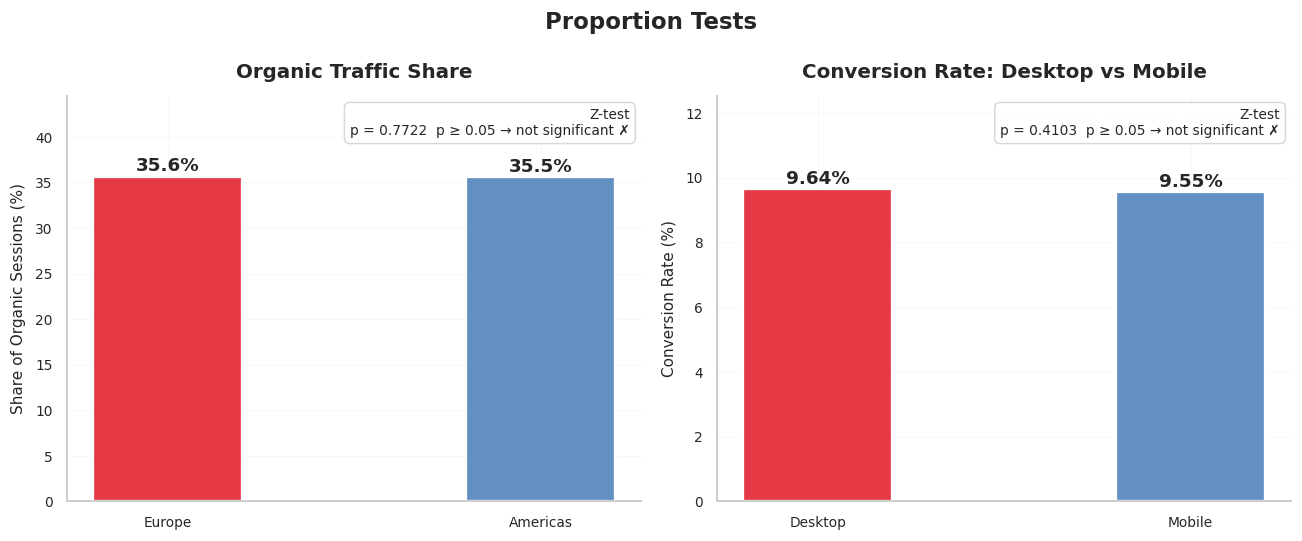

In [ ]:
#  Bar charts for proportion stat tests
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Proportion Tests")


# Organic share — Europe vs Americas
ax = axes[0]
labels_org = ["Europe", "Americas"]
values_org = [prop_eu, prop_am]

bars = ax.bar(labels_org, values_org,
              color=PALETTE_2, width=0.4,
              edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values_org):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val:.1f}%",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.set_title("Organic Traffic Share")
ax.set_ylabel("Share of Organic Sessions (%)")
ax.set_ylim(0, max(values_org) * 1.25)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

result_org = "p < 0.05 → significant ✓" if p_z < 0.05 else "p ≥ 0.05 → not significant ✗"
ax.text(0.98, 0.97, f"Z-test\np = {p_z:.4f}  {result_org}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#D1D5DB", alpha=0.9))


# Conversion rate — Desktop vs Mobile
ax = axes[1]
labels_cr = ["Desktop", "Mobile"]
values_cr = [cr_desktop, cr_mobile]

bars = ax.bar(labels_cr, values_cr,
              color=PALETTE_2, width=0.4,
              edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values_cr):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}%",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.set_title("Conversion Rate: Desktop vs Mobile")
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, max(values_cr) * 1.30)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

result_cr = "p < 0.05 → significant ✓" if p_z_cr < 0.05 else "p ≥ 0.05 → not significant ✗"
ax.text(0.98, 0.97, f"Z-test\np = {p_z_cr:.4f}  {result_cr}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#D1D5DB", alpha=0.9))

plt.tight_layout()
plt.show()

## Chi-square: Device Type vs Traffic Channel

In [ ]:
# Chi-square test of independence
# Question: is there a statistically significant association between device type and traffic channel?
# Choose Chi-square because: Both variables are categorical and independent

INVALID = {"(not set)", "unknown", "None"}

chi_df = ecomm[
    ecomm["device"].notna()          & (~ecomm["device"].isin(INVALID)) &
    ecomm["traffic_channel"].notna() & (~ecomm["traffic_channel"].isin(INVALID))
].copy()

# Contingency table (counts)
contingency = pd.crosstab(chi_df["device"], chi_df["traffic_channel"])

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f" Chi-square: Device type vs Traffic channel,  {p_chi2:.4f} ")
print("✓" if p_chi2 < 0.05 else "✗", "Significant" if p_chi2 < 0.05 else "No significant difference")
print(f"  Chi² statistic : {chi2:.2f}")
print(f"  Degrees of freedom : {dof}")


 Chi-square: Device type vs Traffic channel,  0.7851 
✗ No significant difference
  Chi² statistic : 4.74
  Degrees of freedom : 8


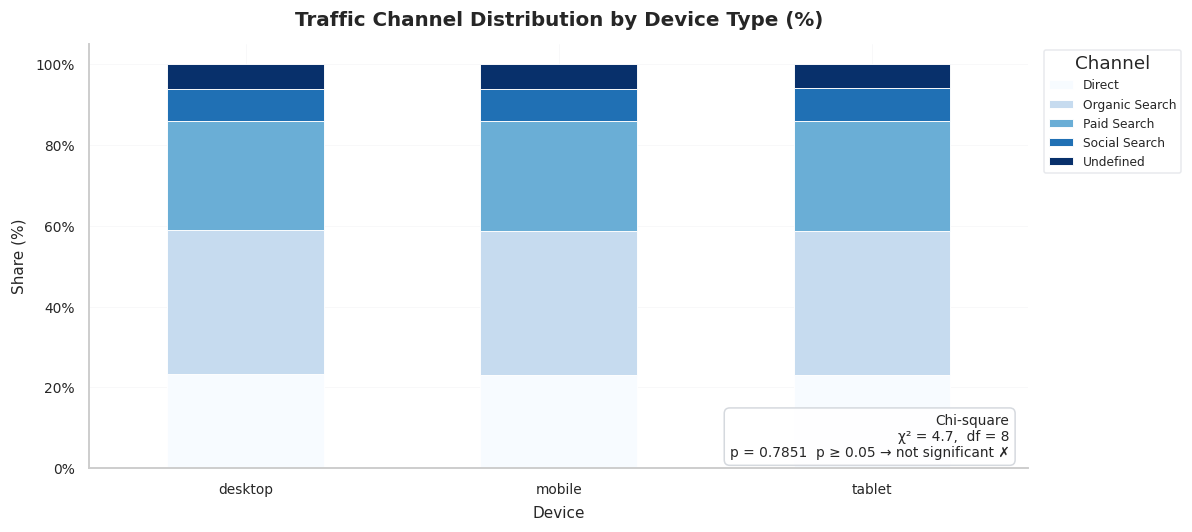

In [ ]:
# Normalise rows to show % distribution of channels within each device
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))

contingency_pct.plot(
    kind="bar", stacked=True,
    colormap=PALETTE_MANY,
    edgecolor="white", linewidth=0.6,
    ax=ax,
)

ax.set_title("Traffic Channel Distribution by Device Type (%)")
ax.set_xlabel("Device")
ax.set_ylabel("Share (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

result_chi = "p < 0.05 → significant ✓" if p_chi2 < 0.05 else "p ≥ 0.05 → not significant ✗"
ax.text(0.98, 0.02,
        f"Chi-square\nχ² = {chi2:.1f},  df = {dof}\np = {p_chi2:.4f}  {result_chi}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#D1D5DB", alpha=0.9))

plt.tight_layout()
plt.show()

## Summary

In [ ]:
summary = pd.DataFrame([
    {
        "Test"      : "Mann-Whitney U",
        "Question"  : "Registered vs Anonymous — daily revenue",
        "p-value"   : round(p_mw, 4),
        "Result"    : "✓ Significant" if p_mw   < 0.05 else "✗ Not significant",
    },
    {
        "Test"      : "Kruskal-Wallis",
        "Question"  : "Sessions across traffic channels",
        "p-value"   : round(p_kw, 4),
        "Result"    : "✓ Significant" if p_kw   < 0.05 else "✗ Not significant",
    },
    {
        "Test"      : "Z-test (proportions)",
        "Question"  : "Organic share: Europe vs Americas",
        "p-value"   : round(p_z, 4),
        "Result"    : "✓ Significant" if p_z    < 0.05 else "✗ Not significant",
    },
    {
        "Test"      : "Z-test (proportions)",
        "Question"  : "Conversion rate: Desktop vs Mobile",
        "p-value"   : round(p_z_cr, 4),
        "Result"    : "✓ Significant" if p_z_cr < 0.05 else "✗ Not significant",
    },
    {
        "Test"      : "Chi-square",
        "Question"  : "Device type vs Traffic channel (independence)",
        "p-value"   : round(p_chi2, 4),
        "Result"    : "✓ Significant" if p_chi2 < 0.05 else "✗ Not significant"}
])

print(" STATISTICAL TESTS SUMMARY\n")
print(summary.to_string(index=False))

 STATISTICAL TESTS SUMMARY

                Test                                      Question  p-value            Result
      Mann-Whitney U       Registered vs Anonymous — daily revenue   0.0000     ✓ Significant
      Kruskal-Wallis              Sessions across traffic channels   0.0000     ✓ Significant
Z-test (proportions)             Organic share: Europe vs Americas   0.7722 ✗ Not significant
Z-test (proportions)            Conversion rate: Desktop vs Mobile   0.4103 ✗ Not significant
          Chi-square Device type vs Traffic channel (independence)   0.7851 ✗ Not significant


Analysis (Mann-Whitney U, p < 0.05) confirmed that registered users generate significantly more revenue than anonymous users.

Kruskal–Wallis analysis revealed that all channel pairs were significantly different (all Bonferroni-adjusted p < 0.05). Traffic acquisition is highly stratified.

There is no statistically significant difference in the share of organic traffic between Europe and the Americas. The platform’s search engine visibility and authority perform with the same structural efficiency on both continents.

Analysis of the conversion rate (desktop vs. mobile) by Z-test shows that the non-significant p-value proves the platform has successfully achieved conversion parity across devices. Mobile users buy at the same rate as desktop users.

The Chi-square test demonstrated that there are no correlation between the user’s device and the traffic channel. Users coming from Social Media, Paid Ads, or Organic Search utilize mobile and desktop devices in identical proportions.

# Final Conclusions

In [ ]:
# Final KPI Summary

kpi_summary = pd.DataFrame([
    {"KPI": "Global Conversion Rate",      "Value": f"{conversion_rate_global:.2f}%"},
    {"KPI": "Global AOV",                  "Value": f"${global_aov:.2f}"},
    {"KPI": "Total Revenue",               "Value": f"${total_revenue:,.0f}"},
    {"KPI": "Total Orders",                "Value": f"{ecomm['product_price'].count():,.0f}"},
    {"KPI": "Unique Sessions",             "Value": f"{ecomm['id_session'].nunique():,}"},
    {"KPI": "Unique Registered Accounts",  "Value": f"{ecomm['id_account'].nunique():,}"},
    {"KPI": "Email Verification Rate",     "Value": f"{email_verified_pct:.2f}%"},
    {"KPI": "Unsubscribe Rate",            "Value": f"{unsubscribed_pct:.2f}%"},
    {"KPI": "Top Revenue/Session Channel", "Value": f"{channel_kpi['revenue_per_session'].idxmax()} (${channel_kpi['revenue_per_session'].max():.2f})"},
    {"KPI": "Top Revenue Continent",       "Value": top3_continents_revenue.iloc[0]['continent']},
    {"KPI": "Top Revenue Country",         "Value": country_leader},
    {"KPI": "Top Category",                "Value": top10_categories_revenue.iloc[0]['product_category']},
])
print(f"Date range : {ecomm['session_date'].min().date()} → {ecomm['session_date'].max().date()}\n")

print("FINAL KPI SUMMARY\n")
print(kpi_summary.to_string(index=False))

Date range : 2020-11-01 → 2021-01-31

FINAL KPI SUMMARY

                        KPI              Value
     Global Conversion Rate              9.59%
                 Global AOV            $953.30
              Total Revenue        $31,971,731
               Total Orders             33,538
            Unique Sessions            349,545
 Unique Registered Accounts             27,945
    Email Verification Rate             71.70%
           Unsubscribe Rate             16.94%
Top Revenue/Session Channel Undefined ($93.12)
      Top Revenue Continent           Americas
        Top Revenue Country      United States
               Top Category  Sofas & armchairs


1. Desktop remains the primary monetisation channel (59% of revenue), which is logical for a category of high-value products requiring detailed viewing.

2. Registered users statistically generate significantly more revenue per day than anonymous users (Mann-Whitney, p < 0.05) — this highlights the importance of loyalty programmes and incentives to register.

3. Traffic channels differ statistically significantly in terms of the number of sessions (Kruskal-Wallis, p < 0.05), whilst the conversion rate for desktop and mobile does NOT differ statistically — therefore, the mobile version of the site converts no worse than the desktop version, despite the lower volume of revenue from mobile .

4. The geographic concentration of revenue in Americas  combined with the universal dominance of Sofas & armchairs suggests the business model is scalable to similar markets without major category-mix changes.

5. The strong Spearman correlation (r = 0.8653) between daily sessions and daily revenue confirms that traffic growth translates predictably into revenue growth.

6. The independence of device type and traffic channel (Chi-square, p ≥ 0.05) combined with conversion-rate parity across devices (Z-test, p ≥ 0.05) indicates the platform is device-agnostic by design.

In [ ]:
ecomm.head()

,session_date,id_session,continent,country,device,browser,mobile_model_name,os,browser_language,traffic_source,traffic_channel,id_account,email_verified,is_unsubscribed,product_category,product_name,product_price,short_description,year_month,day_name
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",2020-11,Sunday
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",2020-11,Sunday
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm",2020-11,Sunday
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",2020-11,Sunday
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",2020-11,Sunday


# Export for Tableau

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
export_cols = [
    "session_date", "year_month", "day_name",
    "id_session", "id_account",
    "continent", "country",
    "device", "browser", "os",
    "traffic_source", "traffic_channel",
    "email_verified", "is_unsubscribed",
    "product_category", "product_name", "product_price",
]

tableau_export = ecomm[export_cols].copy()

# Flag purchase sessions
tableau_export["is_purchase"] = tableau_export["product_price"].notna().astype(int)

# Replace remaining NaNs
for col in ["continent", "country", "device", "browser", "os",
            "traffic_source", "traffic_channel", "product_category", "product_name"]:
    tableau_export[col] = tableau_export[col].fillna("Unknown")

# Save the DataFrame to a CSV file
tableau_export.to_csv("ecommerce_for_tableau.csv", index=False, encoding="utf-8")